# 1. 프로젝트 소개

## POSCO 후판 공정 SCALE 불량 예측 모델

POSCO 후판 공정에서 수집된 압연·가열로 데이터를 분석하여, **SCALE 불량 발생에 영향을 미치는 핵심 공정 변수를 파악하고 불량 여부를 예측하는 머신러닝 모델**을 구축합니다.

원본 데이터의 이상치 제거·인코딩·파생변수 생성 등 전처리를 별도 파일에서 완료한 뒤, 정제된 데이터를 기반으로 로지스틱 회귀부터 트리 기반 앙상블·신경망까지 총 9개 분류 모델을 단계적으로 비교하여 최적 모델을 선정합니다.

---

### 데이터셋 설명

- **출처**: POSCO 후판 공정 내부 데이터 (SCALE불량.csv)
- **원본 크기**: 1,000건 × 21개 컬럼
- **전처리 후 크기**: 799건 × 16개 피처 (rolling_temp=0 제거 + IQR 이상치 제거)
- **타겟 변수**: scale (양품 69% / 불량 31%)

| 컬럼명 | 설명 | 비고 |
|---|---|---|
| **scale** | **SCALE 불량 여부 (타겟 변수)** | **양품 / 불량** |
| rolling_temp | 압연 온도 (°C) | 핵심 변수 (중요도 54%) |
| fur_soak_temp | 가열로 균열 온도 (°C) | — |
| fur_soak_time | 가열로 균열 시간 (분) | — |
| fur_heat_temp | 가열로 가열 온도 (°C) | — |
| fur_heat_time | 가열로 가열 시간 (분) | — |
| fur_total_time | 가열로 총 체류 시간 (분) | — |
| fur_no | 가열로 번호 | 범주형 → 인코딩 |
| fur_input_row | 가열로 입력 열 수 | 범주형 → 인코딩 |
| hsb | 고압수 스케일 제거 장치 여부 | 범주형 → 인코딩 |
| descaling_count | 스케일 제거 횟수 | — |
| rolling_method | 압연 방법 | 범주형 → 인코딩 |
| steel_kind | 강종 | 범주형 → 인코딩 |
| pt_thick | 강판 두께 (mm) | 12 ~ 100 mm |
| pt_width | 강판 폭 (mm) | 1,800 ~ 4,600 mm |
| pt_length | 강판 길이 (mm) | — |
| Temp_Diff_Rolling | 균열온도 - 압연온도 차이 | 파생변수 |
| plate_no | 강판 번호 | 식별자 → 분석 제외 |
| rolling_date | 압연 날짜 | 날짜 → 분석 제외 |
| spec_long / spec_country | 규격 정보 | 분석 제외 |
| work_group | 작업 그룹 | 분석 제외 |

> **주요 데이터 품질 이슈**
> - 
olling_temp = 0 데이터 존재 → 물리적으로 불가능한 값으로 판단하여 제거
> - 수치형 변수 전반에 걸쳐 IQR 기반 이상치 존재 → 순차 제거 방식으로 처리
> - 결측치 없음

# SCALE 불량 예측 - 데이터 탐색 및 전처리 분석

**파일 흐름**
```
SCALE불량.csv (원본 1,000행)
   ↓  rolling_temp=0 제거 + IQR 이상치 제거
SCALE불량_전처리완료.csv (799행)
   ↓  범주형 변수 인코딩
SCALE불량_인코딩완료.csv (799행, 최종)
```

| 슬라이드 | 내용 |
|---|---|
| 1 | 데이터 기본 탐색 (기술통계, 결측치, 타겟 분포) |
| 2 | 물리적 결측치 처리 (rolling_temp=0) |
| 3 | IQR 이상치 탐색 |
| 4 | IQR Before/After 박스플롯 |
| 5 | 전처리 결과 요약 |
| 6 | 인코딩 처리 확인 |

In [3]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

C_GOOD    = '#4A90D9'
C_BAD     = '#E05C5C'
C_BEFORE  = '#7B8FA1'
C_AFTER   = '#4A90D9'
C_OUTLIER = '#F0A500'
BG        = '#F7F9FC'

import os
os.makedirs('output_figures', exist_ok=True)


---
## Slide 1. 데이터 기본 탐색

In [4]:
# 원본 데이터 로드
df_raw = pd.read_csv('SCALE불량.csv', encoding='cp949')
print(f'원본 데이터: {df_raw.shape[0]}행 x {df_raw.shape[1]}열')
df_raw.head()

원본 데이터: 1000행 x 21열


,plate_no,rolling_date,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,...,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group
0,PLT_1001,03JAN2023:07:07:53,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,...,1열,1144,116,1133,59,259,TMCP(온도제어),934,8,1조
1,PLT_1002,03JAN2023:07:21:22,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,...,2열,1144,122,1135,53,238,TMCP(온도제어),937,8,1조
2,PLT_1003,03JAN2023:07:31:15,양품,NV-E36-TM,영국,T,33,3600,19200,적용,...,1열,1129,116,1121,55,258,TMCP(온도제어),889,8,1조
3,PLT_1004,03JAN2023:07:41:01,양품,NV-E36-TM,영국,T,33,3600,19200,적용,...,2열,1152,125,1127,68,266,TMCP(온도제어),885,8,1조
4,PLT_1005,03JAN2023:07:52:40,양품,BV-EH36-TM,프랑스,T,38,3100,13300,적용,...,1열,1140,134,1128,48,246,TMCP(온도제어),873,8,1조


In [5]:
# 컬럼별 타입 / 결측치 확인
info = pd.DataFrame({
    'dtype': df_raw.dtypes,
    'n_null': df_raw.isnull().sum(),
    'null_%': (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'nunique': df_raw.nunique()
})
info

,dtype,n_null,null_%,nunique
plate_no,object,0,0.0,1000
rolling_date,object,0,0.0,1000
scale,object,0,0.0,2
spec_long,object,0,0.0,66
spec_country,object,0,0.0,7
steel_kind,object,0,0.0,2
pt_thick,int64,0,0.0,48
pt_width,int64,0,0.0,29
pt_length,int64,0,0.0,278
hsb,object,0,0.0,2


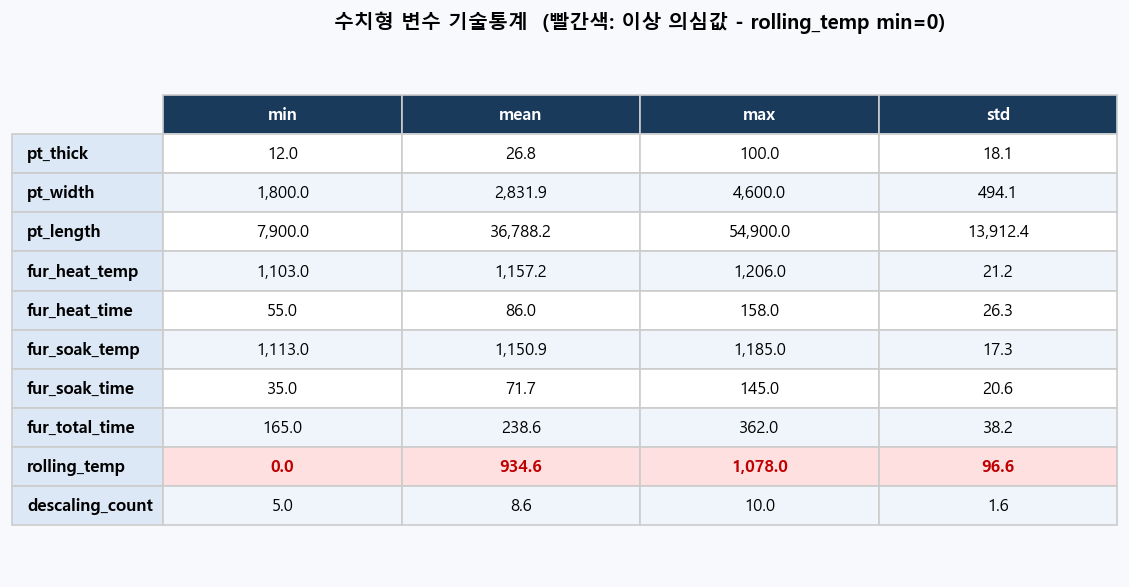

-> rolling_temp 최솟값이 0 -> 다음 슬라이드에서 처리


In [6]:
# 기술통계 - 수치형 변수 (matplotlib 테이블로 출력)
desc = df_raw.describe().T[['min', 'mean', 'max', 'std']]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)
ax.axis('off')

cell_text = [[f'{v:,.1f}' for v in row] for row in desc.values]
tbl = ax.table(
    cellText=cell_text,
    rowLabels=desc.index.tolist(),
    colLabels=['min', 'mean', 'max', 'std'],
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.3, 1.7)

for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1a3a5c')
        cell.set_text_props(color='white', fontweight='bold')
    elif c == -1:
        cell.set_facecolor('#dce8f5')
        cell.set_text_props(fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f0f5fb')
    cell.set_edgecolor('#cccccc')

# rolling_temp 행 강조
rt_idx = desc.index.tolist().index('rolling_temp') + 1
for c in range(4):
    tbl[(rt_idx, c)].set_facecolor('#ffe0e0')
    tbl[(rt_idx, c)].set_text_props(color='#c00000', fontweight='bold')

ax.set_title('수치형 변수 기술통계  (빨간색: 이상 의심값 - rolling_temp min=0)', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('output_figures/slide1_desc_stats.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()
print('-> rolling_temp 최솟값이 0 -> 다음 슬라이드에서 처리')

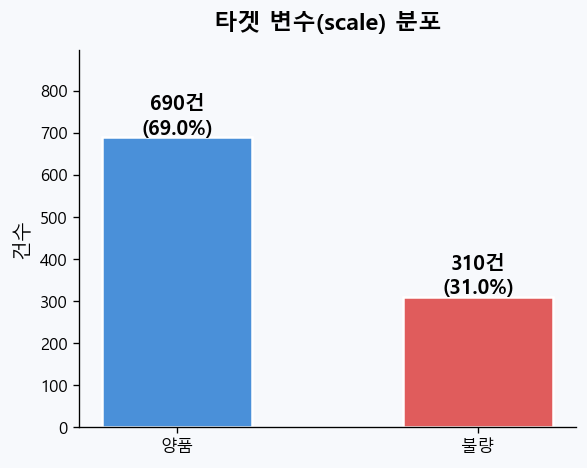

In [7]:
# 타겟 변수(scale) 분포
scale_counts = df_raw['scale'].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars = ax.bar(scale_counts.index, scale_counts.values,
              color=[C_GOOD, C_BAD], edgecolor='white', linewidth=1.5, width=0.5)
for bar, (label, cnt) in zip(bars, scale_counts.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 6,
            f'{cnt}건\n({cnt/len(df_raw)*100:.1f}%)',
            ha='center', fontsize=12, fontweight='bold')

ax.set_title('타겟 변수(scale) 분포', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('건수', fontsize=12)
ax.set_ylim(0, max(scale_counts.values) * 1.3)
plt.tight_layout()
plt.savefig('output_figures/slide1_target_dist.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()

---
## Slide 2. 물리적 결측치 처리: rolling_temp = 0

> 압연 온도가 0도라는 것은 물리적으로 불가능합니다.  
> 센서 오류 또는 입력 누락으로 판단하고 제거합니다.

In [8]:
# rolling_temp=0 행 확인
zero_temp = df_raw[df_raw['rolling_temp'] == 0]
print(f'rolling_temp=0 건수: {len(zero_temp)}건')
zero_temp[['rolling_method', 'rolling_temp', 'steel_kind', 'pt_thick', 'scale']].reset_index()

rolling_temp=0 건수: 6건


,index,rolling_method,rolling_temp,steel_kind,pt_thick,scale
0,53,TMCP(온도제어),0,T,56,양품
1,221,CR(제어압연),0,C,16,양품
2,222,CR(제어압연),0,C,16,양품
3,598,CR(제어압연),0,T,81,양품
4,599,CR(제어압연),0,T,81,양품
5,600,TMCP(온도제어),0,T,40,양품


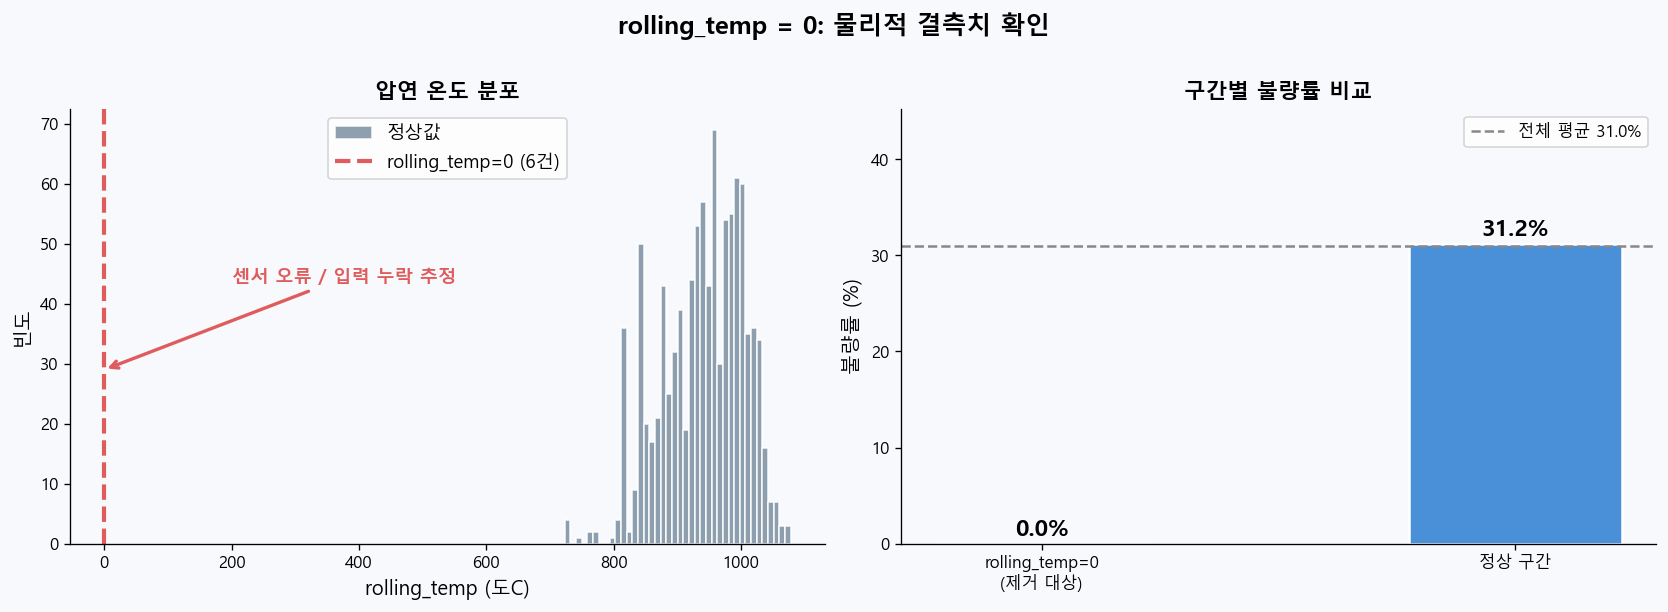

rolling_temp=0 불량률: 0.0%  /  정상 구간: 31.2%
-> 판단: 물리적으로 불가능한 값 -> 6건 제거


In [9]:
# 압연 온도 분포 + rolling_temp=0 구간 불량률
df_raw['scale_bin'] = df_raw['scale'].map({'양품': 0, '불량': 1})
rt_normal = df_raw[df_raw['rolling_temp'] > 0]['rolling_temp']

rate_zero   = df_raw[df_raw['rolling_temp'] == 0]['scale_bin'].mean() * 100
rate_normal = df_raw[df_raw['rolling_temp']  > 0]['scale_bin'].mean() * 100
rate_total  = df_raw['scale_bin'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('rolling_temp = 0: 물리적 결측치 확인', fontsize=15, fontweight='bold', y=1.01)

# 압연 온도 분포
ax = axes[0]
ax.set_facecolor(BG)
ax.hist(rt_normal, bins=40, color=C_BEFORE, alpha=0.85, edgecolor='white', label='정상값')
ax.axvline(0, color=C_BAD, linewidth=2.5, linestyle='--', label=f'rolling_temp=0 ({len(zero_temp)}건)')
ymax = ax.get_ylim()[1]
ax.annotate('센서 오류 / 입력 누락 추정',
            xy=(0, ymax * 0.4), xytext=(200, ymax * 0.6),
            arrowprops=dict(arrowstyle='->', color=C_BAD, lw=2),
            fontsize=11, color=C_BAD, fontweight='bold')
ax.set_xlabel('rolling_temp (도C)', fontsize=12)
ax.set_ylabel('빈도', fontsize=12)
ax.set_title('압연 온도 분포', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

# 불량률 비교
ax2 = axes[1]
ax2.set_facecolor(BG)
groups = ['rolling_temp=0\n(제거 대상)', '정상 구간']
rates  = [rate_zero, rate_normal]
bars = ax2.bar(groups, rates, color=[C_BAD, C_GOOD], edgecolor='white', linewidth=1.5, width=0.45)
for bar, rate in zip(bars, rates):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{rate:.1f}%', ha='center', fontsize=14, fontweight='bold')
ax2.axhline(rate_total, color='#888', linestyle='--', linewidth=1.5, label=f'전체 평균 {rate_total:.1f}%')
ax2.set_ylabel('불량률 (%)', fontsize=12)
ax2.set_ylim(0, max(rates) * 1.45)
ax2.set_title('구간별 불량률 비교', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('output_figures/slide2_rolling_temp_zero.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()

print(f'rolling_temp=0 불량률: {rate_zero:.1f}%  /  정상 구간: {rate_normal:.1f}%')
print('-> 판단: 물리적으로 불가능한 값 -> 6건 제거')

In [10]:
# rolling_temp=0 제거 + 불필요 컬럼 제거 실행
drop_cols = ['plate_no', 'spec_long', 'spec_country', 'rolling_date', 'work_group']
df = df_raw.drop(columns=drop_cols).copy()
df = df[df['rolling_temp'] > 0].reset_index(drop=True)
print(f'제거 후: {len(df)}행')

제거 후: 994행


---
## Slide 3. IQR 이상치 탐색

> **변수 선정 근거**: 전체 수치형 변수의 이상치 건수를 먼저 확인한 뒤,  
> 이상치가 존재하는 변수만 IQR 처리 대상으로 선정합니다.

In [11]:
# 전체 수치형 변수 이상치 건수 확인 (변수 선정 근거)
all_num_cols = ['pt_thick', 'pt_width', 'pt_length',
                'fur_heat_temp', 'fur_heat_time',
                'fur_soak_temp', 'fur_soak_time', 'fur_total_time',
                'rolling_temp', 'descaling_count']

iqr_target = ['pt_thick', 'pt_width', 'fur_heat_time', 'fur_soak_time', 'fur_total_time']

summary = []
for col in all_num_cols:
    data = df[col]
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = int(((data < lower) | (data > upper)).sum())
    summary.append({
        'col': col,
        'min': data.min(), 'max': data.max(),
        'lower_bound': round(lower, 1), 'upper_bound': round(upper, 1),
        'n_outlier': n_out,
        'outlier_%': round(n_out / len(data) * 100, 1),
        'IQR_applied': col in iqr_target,
        'reason': (
            'IQR 적용' if col in iqr_target
            else ('별도 처리 (물리적 결측)' if col == 'rolling_temp'
                  else '이상치 없음 - 제외')
        )
    })

summary_df = pd.DataFrame(summary).set_index('col')
print(summary_df.to_string())
print()
print('-> 이상치 0건인 변수: pt_length, fur_heat_temp, fur_soak_temp, descaling_count -> 처리 불필요')
print('-> rolling_temp: 0값을 별도 처리 완료 + 저온 5건은 CR 공법으로 정상 데이터 확인')

                  min    max  lower_bound  upper_bound  n_outlier  outlier_%  IQR_applied          reason
col                                                                                                      
pt_thick           12    100        -12.0         60.0         93        9.4         True          IQR 적용
pt_width         1800   4600       1600.0       4000.0         19        1.9         True          IQR 적용
pt_length        7900  54900      -6087.5      82212.5          0        0.0        False     이상치 없음 - 제외
fur_heat_temp    1103   1206       1090.5       1222.5          0        0.0        False     이상치 없음 - 제외
fur_heat_time      55    158         10.9        157.9          7        0.7         True          IQR 적용
fur_soak_temp    1113   1185       1094.0       1206.0          0        0.0        False     이상치 없음 - 제외
fur_soak_time      35    145         21.0        117.0         44        4.4         True          IQR 적용
fur_total_time    165    362        130.5     

In [12]:
# IQR 경계 계산 (순차 제거 방식 - preprocess.py와 동일)
iqr_bounds_seq = {}
df_tmp = df.copy()

for col in iqr_target:
    Q1 = df_tmp[col].quantile(0.25)
    Q3 = df_tmp[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_bounds_seq[col] = (lower, upper)

    mask = (df_tmp[col] < lower) | (df_tmp[col] > upper)
    n_removed = mask.sum()
    df_tmp = df_tmp[~mask].reset_index(drop=True)
    print(f'{col}: lower={lower:.1f}, upper={upper:.1f}, 제거={n_removed}건, 잔여={len(df_tmp)}행')

print(f'\nIQR 처리 후 최종: {len(df_tmp)}행')

pt_thick: lower=-12.0, upper=60.0, 제거=93건, 잔여=901행
pt_width: lower=1450.0, upper=4250.0, 제거=11건, 잔여=890행
fur_heat_time: lower=15.9, upper=146.9, 제거=28건, 잔여=862행
fur_soak_time: lower=25.5, upper=109.5, 제거=53건, 잔여=809행
fur_total_time: lower=144.0, upper=312.0, 제거=10건, 잔여=799행

IQR 처리 후 최종: 799행


---
## Slide 4. IQR Before / After 박스플롯

Before(IQR 전): 994행  |  After(IQR 후): 799행


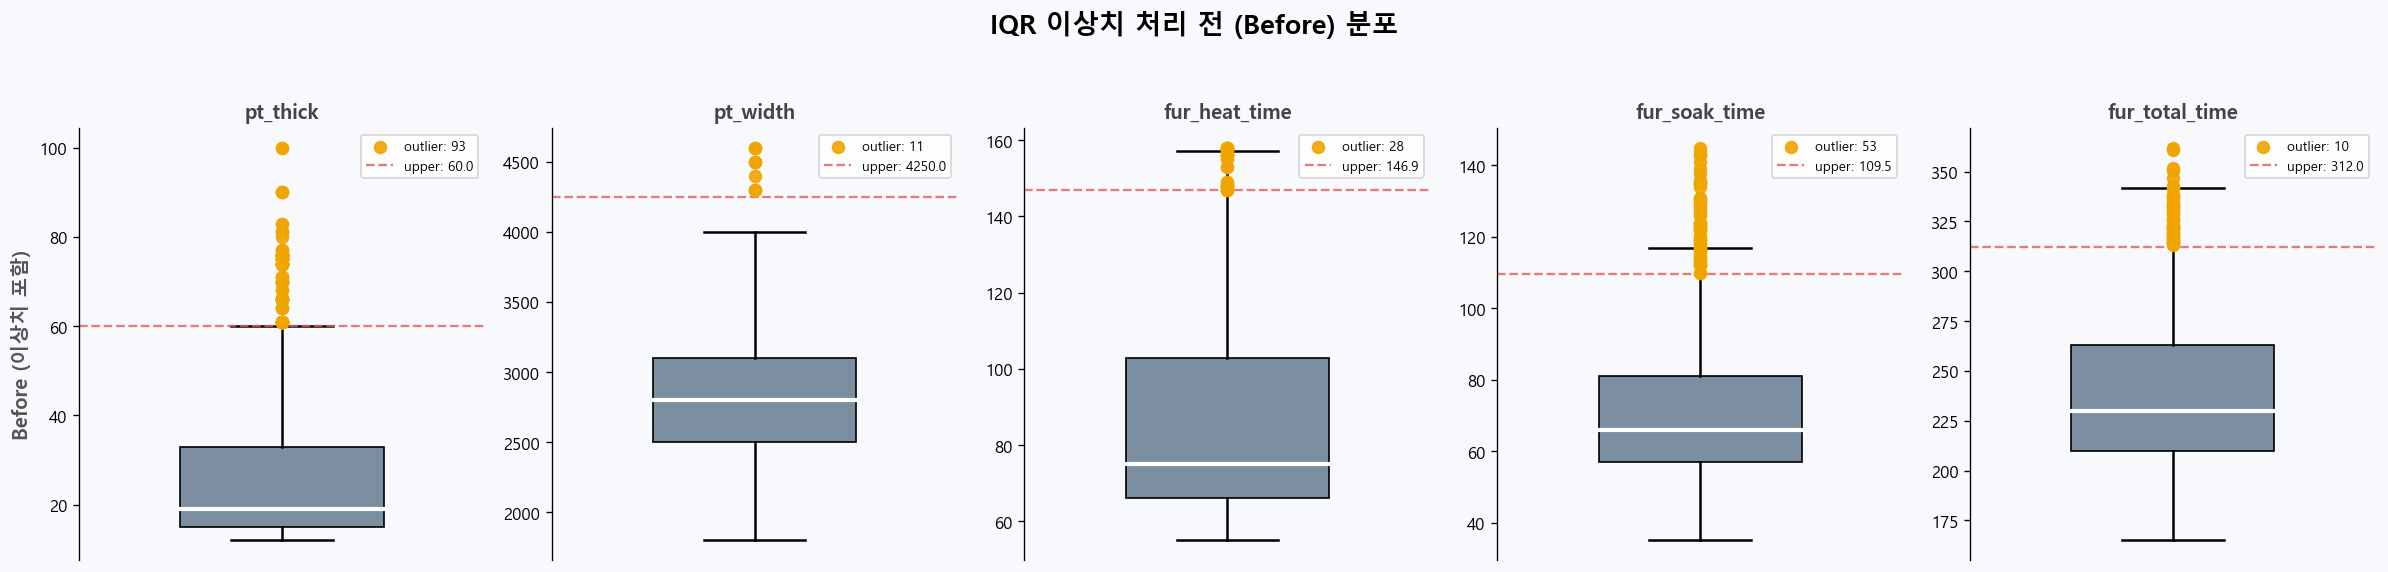

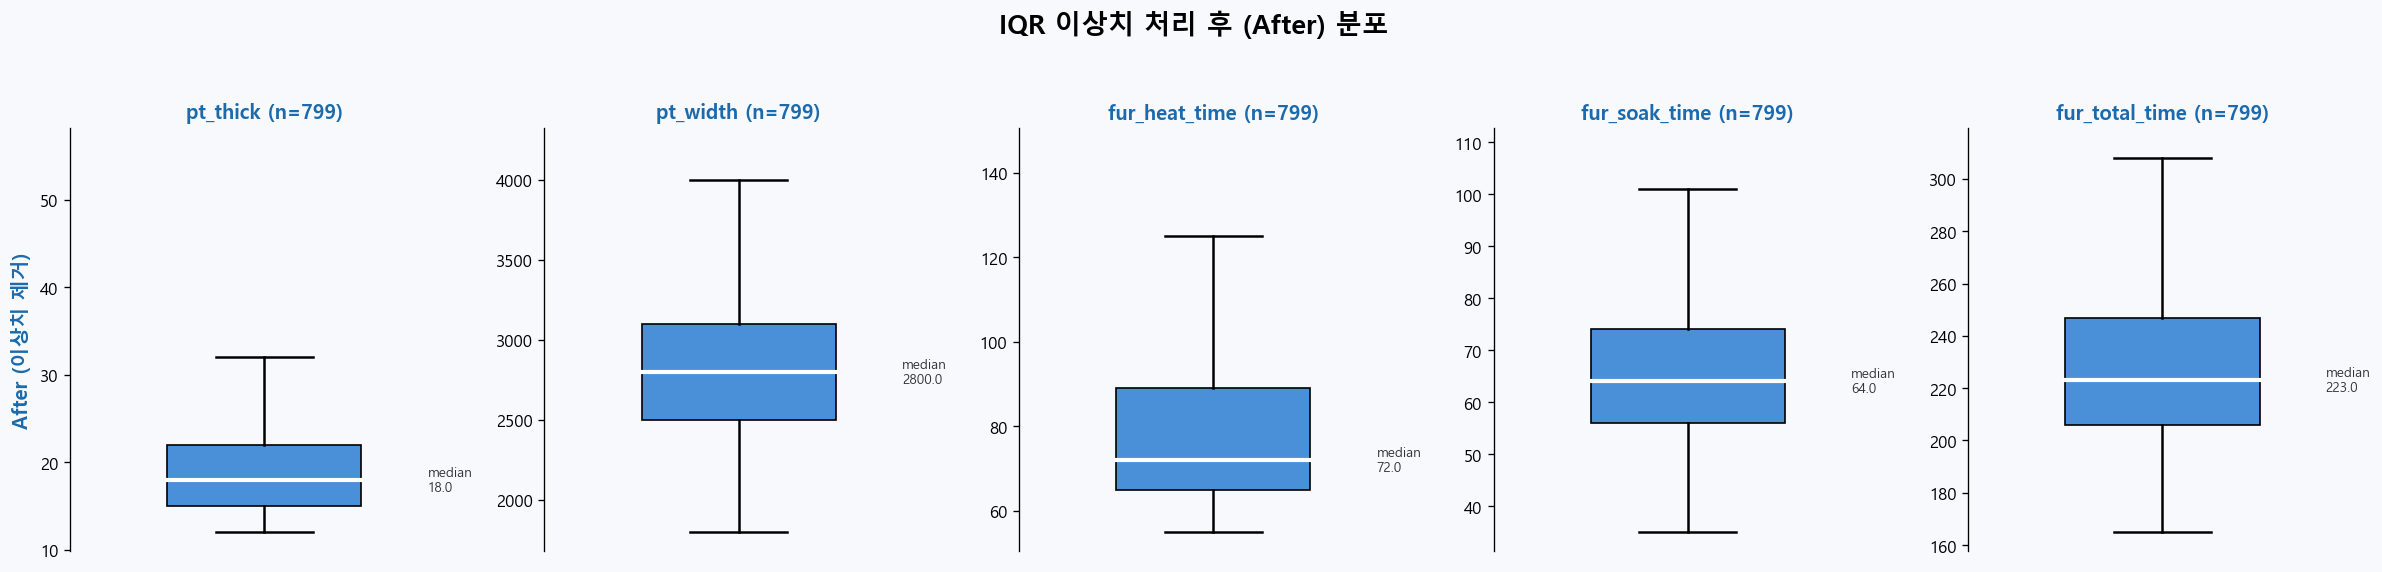

In [13]:
# 전처리 완료 파일 로드 (After)
df_after = pd.read_csv('SCALE불량_인코딩완료.csv', encoding='utf-8-sig')
print(f'Before(IQR 전): {len(df)}행  |  After(IQR 후): {len(df_after)}행')

# 실제 제거 건수 (preprocess.py 순차 실행 기준)
actual_removed = {
    'pt_thick':       93,
    'pt_width':       11,
    'fur_heat_time':  28,
    'fur_soak_time':  53,
    'fur_total_time': 10,
}

bp_props = dict(
    patch_artist=True, widths=0.5,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=4, alpha=0)
)

# ---------------- Before Boxplot ----------------
fig_b, axes_b = plt.subplots(1, 5, figsize=(20, 4.5))
fig_b.patch.set_facecolor(BG)
fig_b.suptitle('IQR 이상치 처리 전 (Before) 분포', fontsize=16, fontweight='bold', y=1.05)

for i, col in enumerate(iqr_target):
    ax_b = axes_b[i]
    ax_b.set_facecolor(BG)

    data_b = df[col].dropna()
    lower, upper = iqr_bounds_seq[col]
    n_out = actual_removed[col]

    bp1 = ax_b.boxplot(data_b, **bp_props)
    bp1['boxes'][0].set_facecolor(C_BEFORE)
    outliers = data_b[(data_b < lower) | (data_b > upper)]
    ax_b.scatter([1] * len(outliers), outliers,
                 color=C_OUTLIER, zorder=5, s=50, alpha=0.9, label=f'outlier: {n_out}')
    ax_b.axhline(upper, color=C_BAD, linestyle='--', linewidth=1.4, alpha=0.8,
                 label=f'upper: {upper:.1f}')
    if lower > data_b.min():
        ax_b.axhline(lower, color=C_BAD, linestyle=':', linewidth=1.4, alpha=0.8,
                     label=f'lower: {lower:.1f}')
    ax_b.set_title(f'{col}', fontsize=12, fontweight='bold', color='#444')
    ax_b.set_xticks([])
    ax_b.spines[['top', 'right', 'bottom']].set_visible(False)
    ax_b.legend(fontsize=8, loc='upper right')

axes_b[0].set_ylabel('Before (이상치 포함)', fontsize=12, fontweight='bold', color='#555')
plt.tight_layout()
plt.savefig('output_figures/slide4_iqr_boxplot_before.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()

# ---------------- After Boxplot ----------------
fig_a, axes_a = plt.subplots(1, 5, figsize=(20, 4.5))
fig_a.patch.set_facecolor(BG)
fig_a.suptitle('IQR 이상치 처리 후 (After) 분포', fontsize=16, fontweight='bold', y=1.05)

for i, col in enumerate(iqr_target):
    ax_a = axes_a[i]
    ax_a.set_facecolor(BG)

    data_a = df_after[col].dropna()

    bp2 = ax_a.boxplot(data_a, **bp_props)
    bp2['boxes'][0].set_facecolor(C_AFTER)
    ax_a.set_title(f'{col} (n={len(data_a)})', fontsize=12, fontweight='bold', color='#1a6aad')
    ax_a.set_xticks([])
    ax_a.spines[['top', 'right', 'bottom']].set_visible(False)
    ax_a.text(1.42, data_a.median(),
              f'median\n{data_a.median():.1f}', va='center', fontsize=8, color='#333')

axes_a[0].set_ylabel('After (이상치 제거)', fontsize=12, fontweight='bold', color='#1a6aad')
plt.tight_layout()
plt.savefig('output_figures/slide4_iqr_boxplot_after.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()

---
## Slide 5. 전처리 결과 요약

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


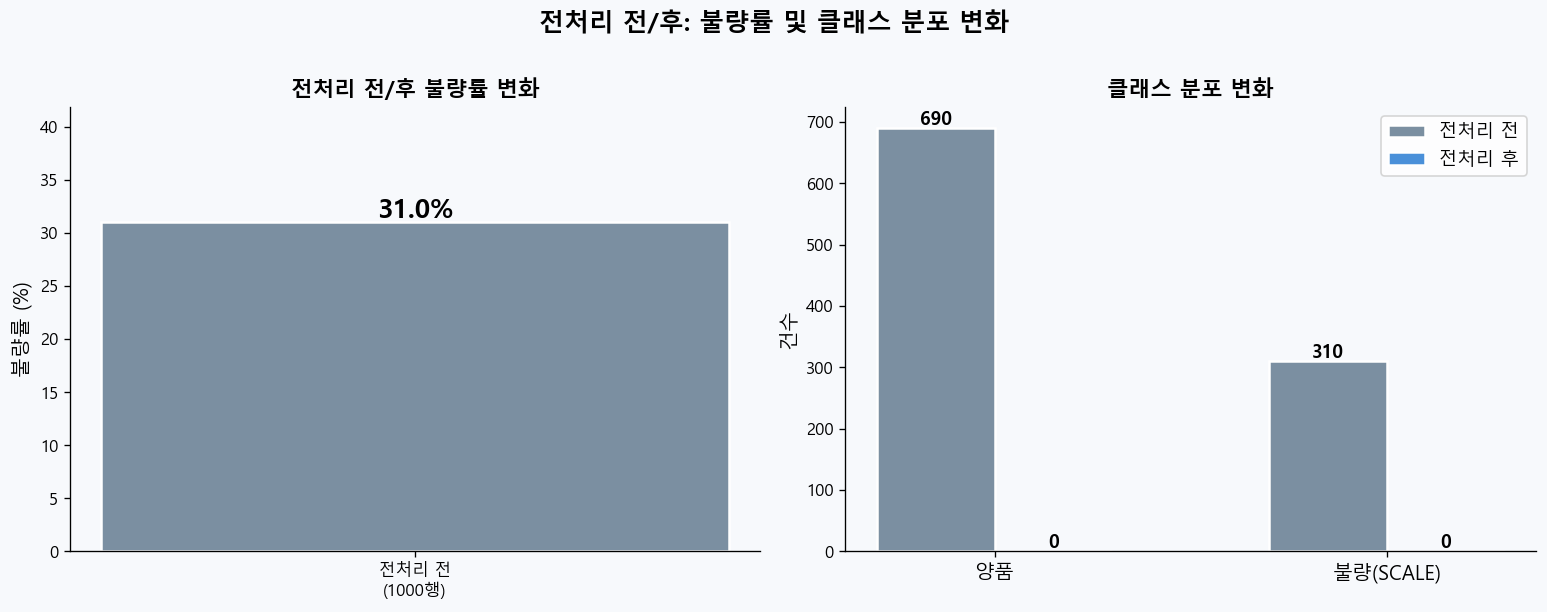

불량률: 31.0% -> nan%  (nan%p)
이상치 구간이 정상 구간보다 불량률이 낮아서 제거 후 불량률 소폭 상승


In [14]:
# 전처리 전/후 불량률 및 클래스 분포 변화
df_after['scale_bin'] = df_after['scale'].map({'양품': 0, '불량': 1})

n_before = len(df_raw)
n_after  = len(df_after)
rate_before = df_raw['scale_bin'].mean() * 100
rate_after  = df_after['scale_bin'].mean() * 100
delta = rate_after - rate_before
sign  = '+' if delta >= 0 else ''

n_good_b = (df_raw['scale_bin'] == 0).sum()
n_bad_b  = (df_raw['scale_bin'] == 1).sum()
n_good_a = (df_after['scale_bin'] == 0).sum()
n_bad_a  = (df_after['scale_bin'] == 1).sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('전처리 전/후: 불량률 및 클래스 분포 변화', fontsize=15, fontweight='bold', y=1.01)

ax = axes[0]
ax.set_facecolor(BG)
stages = [f'전처리 전\n({n_before}행)', f'전처리 후\n({n_after}행)']
rates_ = [rate_before, rate_after]
bars = ax.bar(stages, rates_, color=[C_BEFORE, C_AFTER], edgecolor='white', linewidth=1.5, width=0.45)
for bar, rate in zip(bars, rates_):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{rate:.1f}%', ha='center', fontsize=16, fontweight='bold')
ax.set_ylim(0, max(rates_) * 1.35)
ax.set_ylabel('불량률 (%)', fontsize=12)
ax.set_title('전처리 전/후 불량률 변화', fontsize=13, fontweight='bold')
ax.annotate(f'변화: {sign}{delta:.2f}%p',
            xy=(1, rate_after), xytext=(0.5, max(rates_) * 1.22),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.5),
            fontsize=12, color='#333', ha='center')

ax2 = axes[1]
ax2.set_facecolor(BG)
x = np.arange(2)
width = 0.3
bars1 = ax2.bar(x - width/2, [n_good_b, n_bad_b], width, label='전처리 전', color=C_BEFORE, edgecolor='white', linewidth=1.5)
bars2 = ax2.bar(x + width/2, [n_good_a, n_bad_a], width, label='전처리 후', color=C_AFTER,  edgecolor='white', linewidth=1.5)
for bar in list(bars1) + list(bars2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(int(bar.get_height())), ha='center', fontsize=11, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(['양품', '불량(SCALE)'], fontsize=12)
ax2.set_ylabel('건수', fontsize=12)
ax2.set_title('클래스 분포 변화', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig('output_figures/slide5_before_after_summary.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()

print(f'불량률: {rate_before:.1f}% -> {rate_after:.1f}%  ({sign}{delta:.2f}%p)')
print('이상치 구간이 정상 구간보다 불량률이 낮아서 제거 후 불량률 소폭 상승')

In [15]:
# 전처리 요약 출력
print('=' * 55)
print('전처리 결과 최종 요약')
print('=' * 55)
print(f'  원본 행 수        : {n_before}행')
print(f'  전처리 후 행 수   : {n_after}행')
print(f'  총 제거 행 수     : {n_before - n_after}행  ({(n_before-n_after)/n_before*100:.1f}%)')
print()
print('  [제거 내역]')
print(f'    rolling_temp=0 (물리적 결측):  6건')
for col, cnt in actual_removed.items():
    print(f'    {col} IQR 이상치: {cnt}건')
print()
print(f'  불량률: {rate_before:.1f}%  ->  {rate_after:.1f}%  ({sign}{delta:.2f}%p)')
print('=' * 55)

전처리 결과 최종 요약
  원본 행 수        : 1000행
  전처리 후 행 수   : 799행
  총 제거 행 수     : 201행  (20.1%)

  [제거 내역]
    rolling_temp=0 (물리적 결측):  6건
    pt_thick IQR 이상치: 93건
    pt_width IQR 이상치: 11건
    fur_heat_time IQR 이상치: 28건
    fur_soak_time IQR 이상치: 53건
    fur_total_time IQR 이상치: 10건

  불량률: 31.0%  ->  nan%  (nan%p)


---
## Slide 6. 인코딩 처리 확인

최종 파일: `SCALE불량_인코딩완료.csv`

In [16]:
df_enc = pd.read_csv('SCALE불량_인코딩완료.csv', encoding='utf-8-sig')
print(f'최종 파일: {df_enc.shape[0]}행 x {df_enc.shape[1]}열')
df_enc.head()

최종 파일: 799행 x 16열


,scale,steel_kind,pt_thick,pt_width,pt_length,hsb,fur_no,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count
0,0,1,32,3700,15100,1,1,1,1144,116,1133,59,259,1,934,8
1,0,1,32,3700,15100,1,1,2,1144,122,1135,53,238,1,937,8
2,0,1,33,3600,19200,1,2,1,1129,116,1121,55,258,1,889,8
3,0,1,33,3600,19200,1,2,2,1152,125,1127,68,266,1,885,8
4,0,1,38,3100,13300,1,3,1,1140,134,1128,48,246,1,873,8


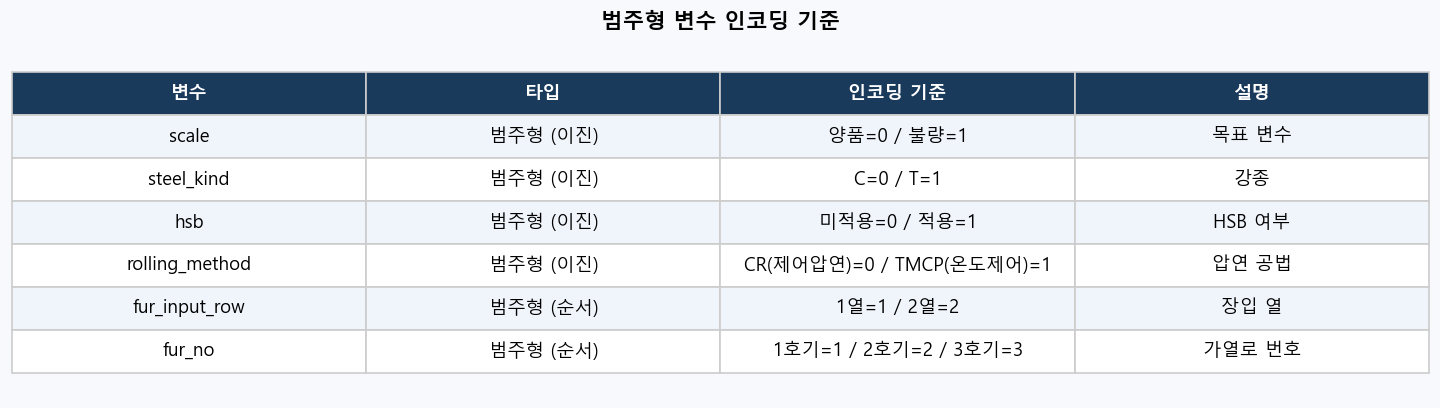

In [17]:
# 인코딩 기준 표
encoding_table = [
    ['scale',          '범주형 (이진)',  '양품=0 / 불량=1',                 '목표 변수'],
    ['steel_kind',     '범주형 (이진)',  'C=0 / T=1',                      '강종'],
    ['hsb',            '범주형 (이진)',  '미적용=0 / 적용=1',                'HSB 여부'],
    ['rolling_method', '범주형 (이진)',  'CR(제어압연)=0 / TMCP(온도제어)=1', '압연 공법'],
    ['fur_input_row',  '범주형 (순서)',  '1열=1 / 2열=2',                   '장입 열'],
    ['fur_no',         '범주형 (순서)',  '1호기=1 / 2호기=2 / 3호기=3',      '가열로 번호'],
]

fig, ax = plt.subplots(figsize=(12, 3.5))
fig.patch.set_facecolor(BG)
ax.axis('off')

tbl = ax.table(
    cellText=encoding_table,
    colLabels=['변수', '타입', '인코딩 기준', '설명'],
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 2.0)

for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1a3a5c')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 1:
        cell.set_facecolor('#f0f5fb')
    cell.set_edgecolor('#cccccc')

ax.set_title('범주형 변수 인코딩 기준', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('output_figures/slide6_encoding_table.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()

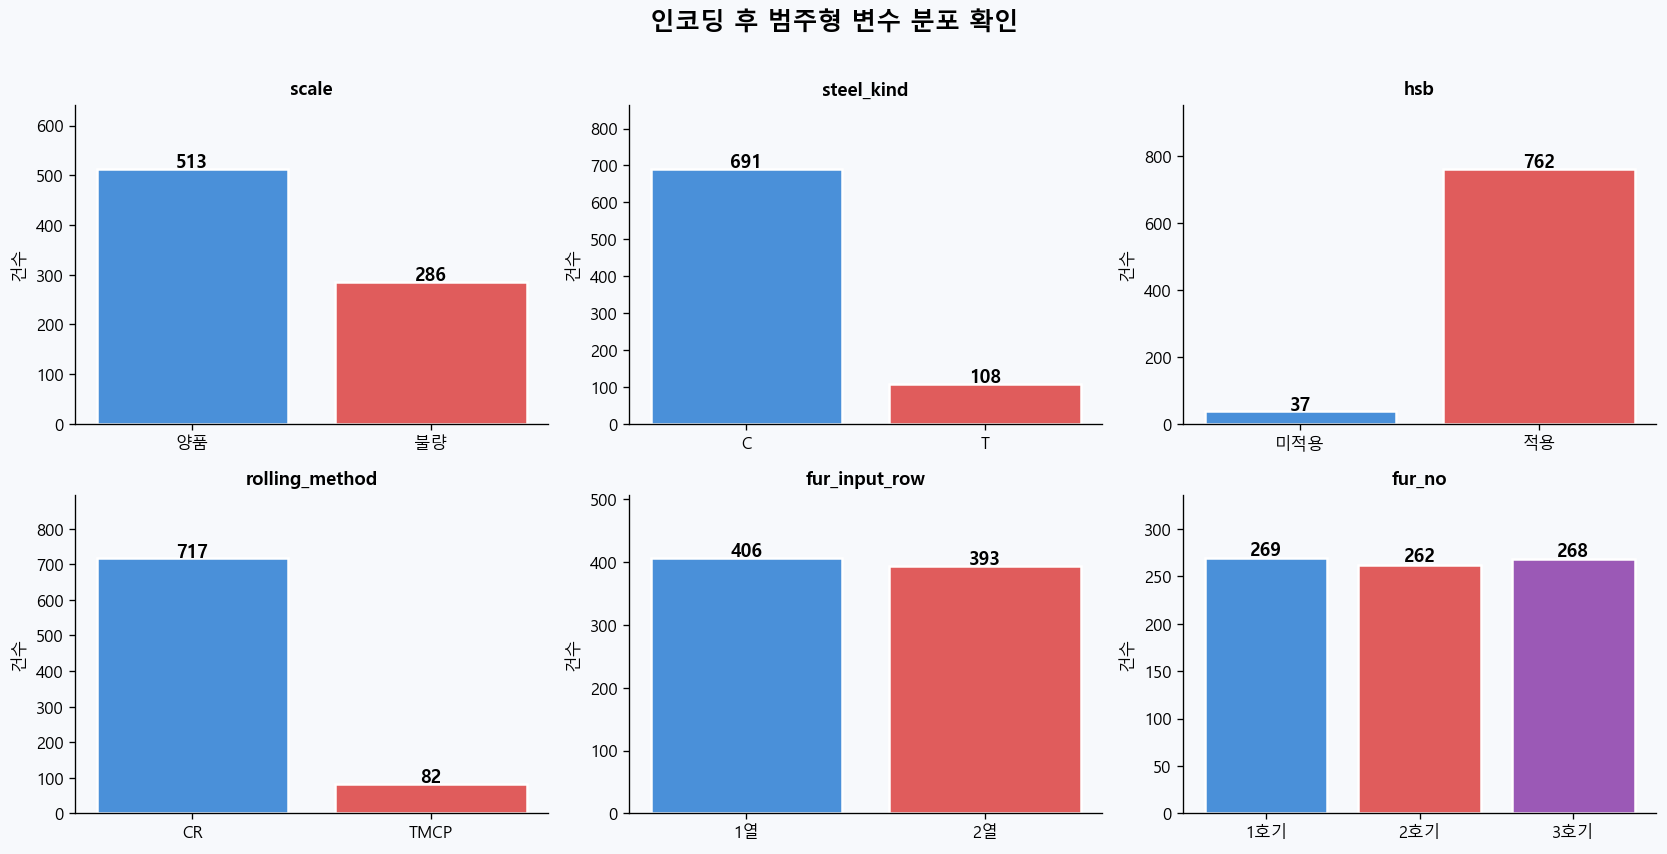


[최종 파일 확인]
  파일명: SCALE불량_인코딩완료.csv
  shape : 799행 x 16열
  컬럼  : ['scale', 'steel_kind', 'pt_thick', 'pt_width', 'pt_length', 'hsb', 'fur_no', 'fur_input_row', 'fur_heat_temp', 'fur_heat_time', 'fur_soak_temp', 'fur_soak_time', 'fur_total_time', 'rolling_method', 'rolling_temp', 'descaling_count']
  결측치: 0개


In [18]:
# 인코딩 후 분포 확인 (범주형 6개)
cat_cols = ['scale', 'steel_kind', 'hsb', 'rolling_method', 'fur_input_row', 'fur_no']
cat_labels = {
    'scale':          {0: '양품', 1: '불량'},
    'steel_kind':     {0: 'C', 1: 'T'},
    'hsb':            {0: '미적용', 1: '적용'},
    'rolling_method': {0: 'CR', 1: 'TMCP'},
    'fur_input_row':  {1: '1열', 2: '2열'},
    'fur_no':         {1: '1호기', 2: '2호기', 3: '3호기'},
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('인코딩 후 범주형 변수 분포 확인', fontsize=15, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    ax.set_facecolor(BG)
    vc = df_enc[col].value_counts().sort_index()
    colors = [C_GOOD, C_BAD, '#9B59B6'] if col == 'fur_no' else [C_GOOD, C_BAD]
    bars = ax.bar(
        [str(cat_labels[col].get(k, k)) for k in vc.index],
        vc.values,
        color=colors[:len(vc)], edgecolor='white', linewidth=1.5
    )
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(val), ha='center', fontsize=11, fontweight='bold')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('건수', fontsize=10)
    ax.set_ylim(0, max(vc.values) * 1.25)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('output_figures/slide6_encoding_dist.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()

print('\n[최종 파일 확인]')
print(f'  파일명: SCALE불량_인코딩완료.csv')
print(f'  shape : {df_enc.shape[0]}행 x {df_enc.shape[1]}열')
print(f'  컬럼  : {df_enc.columns.tolist()}')
print(f'  결측치: {df_enc.isnull().sum().sum()}개')

# 데이터 모델링
- 본 내용은 위에서 정제된 데이터를 가지고 모델링을 진행함

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set(font='Malgun Gothic', rc={'axes.unicode_minus': False}, style='whitegrid')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              precision_score, recall_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
import statsmodels.api as sm


In [20]:
import matplotlib.pyplot as plt

print(plt.rcParams['font.family'])
print(plt.rcParams['axes.unicode_minus'])

['Malgun Gothic']
False


In [21]:
df = pd.read_excel(r"SCALE불량_최종.xlsx")
df.head()


ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

### 데이터 확인

In [ ]:
print("=== 데이터 정보 및 결측치 확인 ===")
df.info()
print("\n=== 기술 통계량 확인 ===")
display(df.describe())
print("\n=== 결측치 빈도 집계 ===")
print(df.isnull().sum())

=== 데이터 정보 및 결측치 확인 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 799 entries, 0 to 798
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   scale              799 non-null    int64
 1   steel_kind         799 non-null    int64
 2   pt_thick           799 non-null    int64
 3   pt_width           799 non-null    int64
 4   pt_length          799 non-null    int64
 5   hsb                799 non-null    int64
 6   fur_no             799 non-null    int64
 7   fur_input_row      799 non-null    int64
 8   fur_heat_temp      799 non-null    int64
 9   fur_heat_time      799 non-null    int64
 10  fur_soak_temp      799 non-null    int64
 11  fur_soak_time      799 non-null    int64
 12  fur_total_time     799 non-null    int64
 13  rolling_method     799 non-null    int64
 14  rolling_temp       799 non-null    int64
 15  descaling_count    799 non-null    int64
 16  Temp_Diff_Rolling  799 non-null    int

,scale,steel_kind,pt_thick,pt_width,pt_length,hsb,fur_no,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,Temp_Diff_Rolling
count,799.000000,799.000000,799.000000,799.000000,799.00000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000
mean,0.357947,0.135169,21.272841,2844.430538,40080.97622,0.953692,1.998748,1.491865,1160.742178,80.948686,1155.693367,66.640801,228.473091,0.102628,956.370463,8.924906,199.322904
std,0.479697,0.342118,9.747085,465.276370,11262.38838,0.210283,0.820324,0.500247,20.843458,23.124944,15.037958,15.162772,30.326733,0.303663,55.093749,1.329016,49.944966
min,0.000000,0.000000,12.000000,1800.000000,10900.00000,0.000000,1.000000,1.000000,1106.000000,55.000000,1113.000000,35.000000,165.000000,0.000000,723.000000,5.000000,68.000000
25%,0.000000,0.000000,15.000000,2500.000000,34250.00000,1.000000,1.000000,1.000000,1146.000000,65.000000,1148.000000,56.000000,206.000000,0.000000,927.000000,8.000000,161.500000
50%,0.000000,0.000000,18.000000,2800.000000,42000.00000,1.000000,2.000000,1.000000,1164.000000,72.000000,1159.000000,64.000000,223.000000,0.000000,962.000000,10.000000,193.000000
75%,1.000000,0.000000,22.000000,3100.000000,49700.00000,1.000000,3.000000,2.000000,1175.000000,89.000000,1166.000000,74.000000,247.000000,0.000000,998.000000,10.000000,234.000000
max,1.000000,1.000000,56.000000,4200.000000,54900.00000,1.000000,3.000000,2.000000,1206.000000,146.000000,1185.000000,109.000000,312.000000,1.000000,1078.000000,10.000000,406.000000



=== 결측치 빈도 집계 ===
scale                0
steel_kind           0
pt_thick             0
pt_width             0
pt_length            0
hsb                  0
fur_no               0
fur_input_row        0
fur_heat_temp        0
fur_heat_time        0
fur_soak_temp        0
fur_soak_time        0
fur_total_time       0
rolling_method       0
rolling_temp         0
descaling_count      0
Temp_Diff_Rolling    0
dtype: int64


#### 상관계수 확인

In [ ]:
correlations = df.corr()['scale'].sort_values(ascending=False)

print("=== scale에 영향을 주는 핵심 인자 (상관계수 순) ===")
print(correlations)

=== scale에 영향을 주는 핵심 인자 (상관계수 순) ===
scale                1.000000
rolling_temp         0.525328
fur_soak_temp        0.267124
fur_heat_temp        0.178439
fur_heat_time        0.071245
fur_no               0.052092
pt_thick             0.051450
fur_total_time       0.001524
fur_input_row       -0.055737
pt_length           -0.059556
fur_soak_time       -0.157689
descaling_count     -0.187762
rolling_method      -0.209492
steel_kind          -0.234101
pt_width            -0.268418
hsb                 -0.295120
Temp_Diff_Rolling   -0.499055
Name: scale, dtype: float64


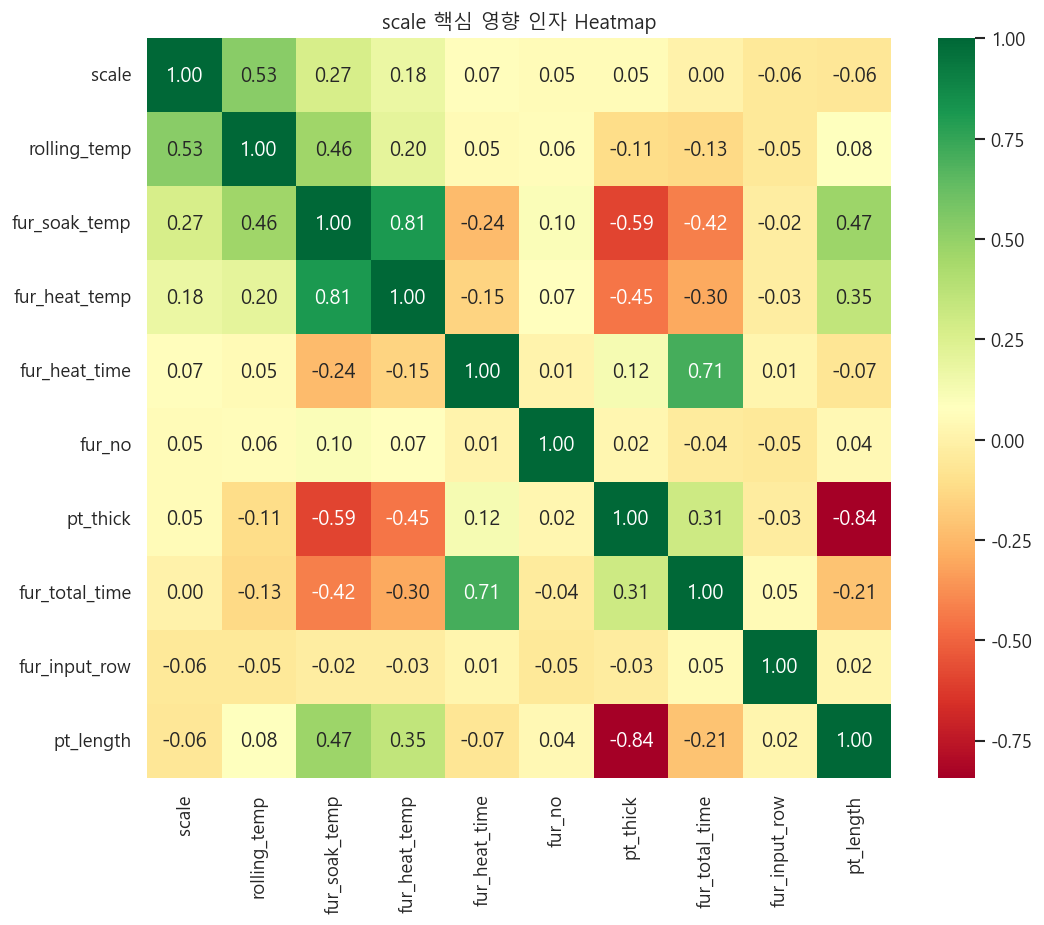

In [ ]:
# 상관관계 상위 10개 항목만 추출
top_features = correlations.index[:10]
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("scale 핵심 영향 인자 Heatmap")
plt.show()

**핵심 영향 인자 식별:** 상관계수 및 히트맵 분석 결과, `rolling_temp`(0.53)가 타겟 변수에 가장 지배적인 양(+)의 영향을 미치며, 이는 온도 상승이 스케일 발생을 촉진한다는 물리적 공정 원리와 일치합니다.

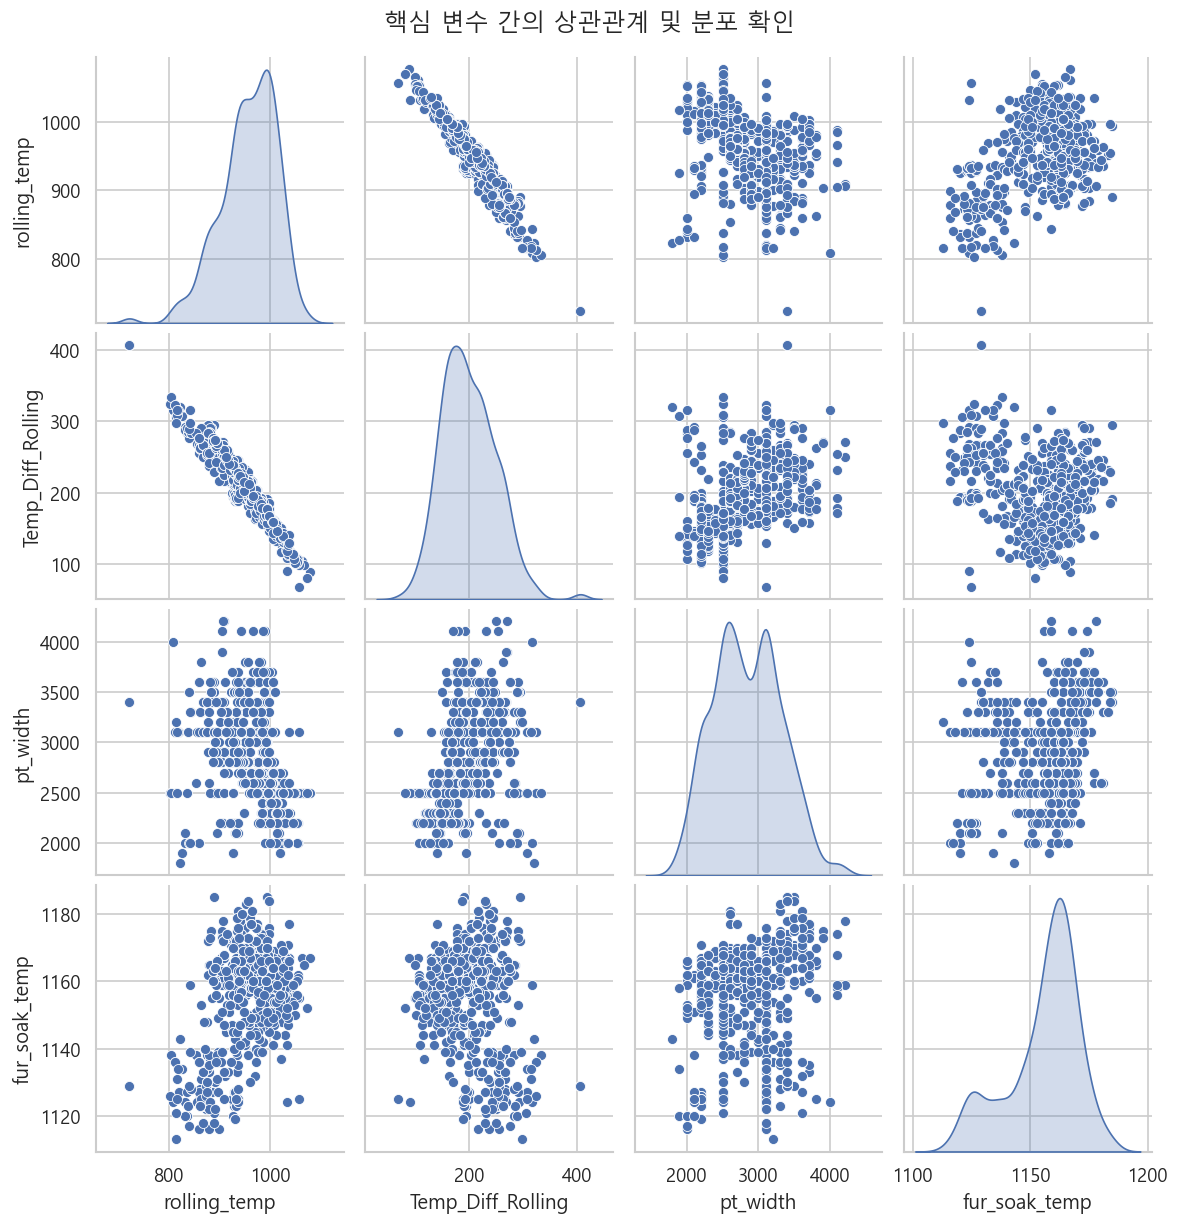

In [ ]:
# 상위 핵심 변수들만 골라서 페어 플롯 시각화
sns.pairplot(df[['rolling_temp', 'Temp_Diff_Rolling', 'pt_width', 'fur_soak_temp']], diag_kind='kde')
plt.suptitle('핵심 변수 간의 상관관계 및 분포 확인', y=1.02)
plt.show()

**변수 간 독립성 및 위험 요소:** 페어 플롯을 통해 `rolling_temp`와 `Temp_Diff_Rolling` 사이의 강한 다중공선성을 확인하였으며, 이는 모델 해석 시 변수 중요도가 분산될 수 있는 요소임을 파악했습니다.

- Step 2. EDA 및 상관관계 분석


In [ ]:
# Price_log와 각 변수의 Pearson 상관계수 계산 및 정렬
corr_matrix = df.corr()
corr_with_target = corr_matrix['scale'].drop('scale').sort_values(key=abs, ascending=False)

corr_summary = pd.DataFrame({
    '변수명': corr_with_target.index,
    '상관계수': corr_with_target.values.round(4),
    '방향': ['양(+)' if v > 0 else '음(-)' for v in corr_with_target.values],
    '강도': ['강함' if abs(v) >= 0.5 else '보통' if abs(v) >= 0.3 else '약함'
             for v in corr_with_target.values]
})

print('=== scale과 각 변수의 상관계수 (절대값 내림차순) ===')
display(corr_summary)


=== scale과 각 변수의 상관계수 (절대값 내림차순) ===


,변수명,상관계수,방향,강도
0,rolling_temp,0.5253,양(+),강함
1,Temp_Diff_Rolling,-0.4991,음(-),보통
2,hsb,-0.2951,음(-),약함
3,pt_width,-0.2684,음(-),약함
4,fur_soak_temp,0.2671,양(+),약함
5,steel_kind,-0.2341,음(-),약함
6,rolling_method,-0.2095,음(-),약함
7,descaling_count,-0.1878,음(-),약함
8,fur_heat_temp,0.1784,양(+),약함
9,fur_soak_time,-0.1577,음(-),약함


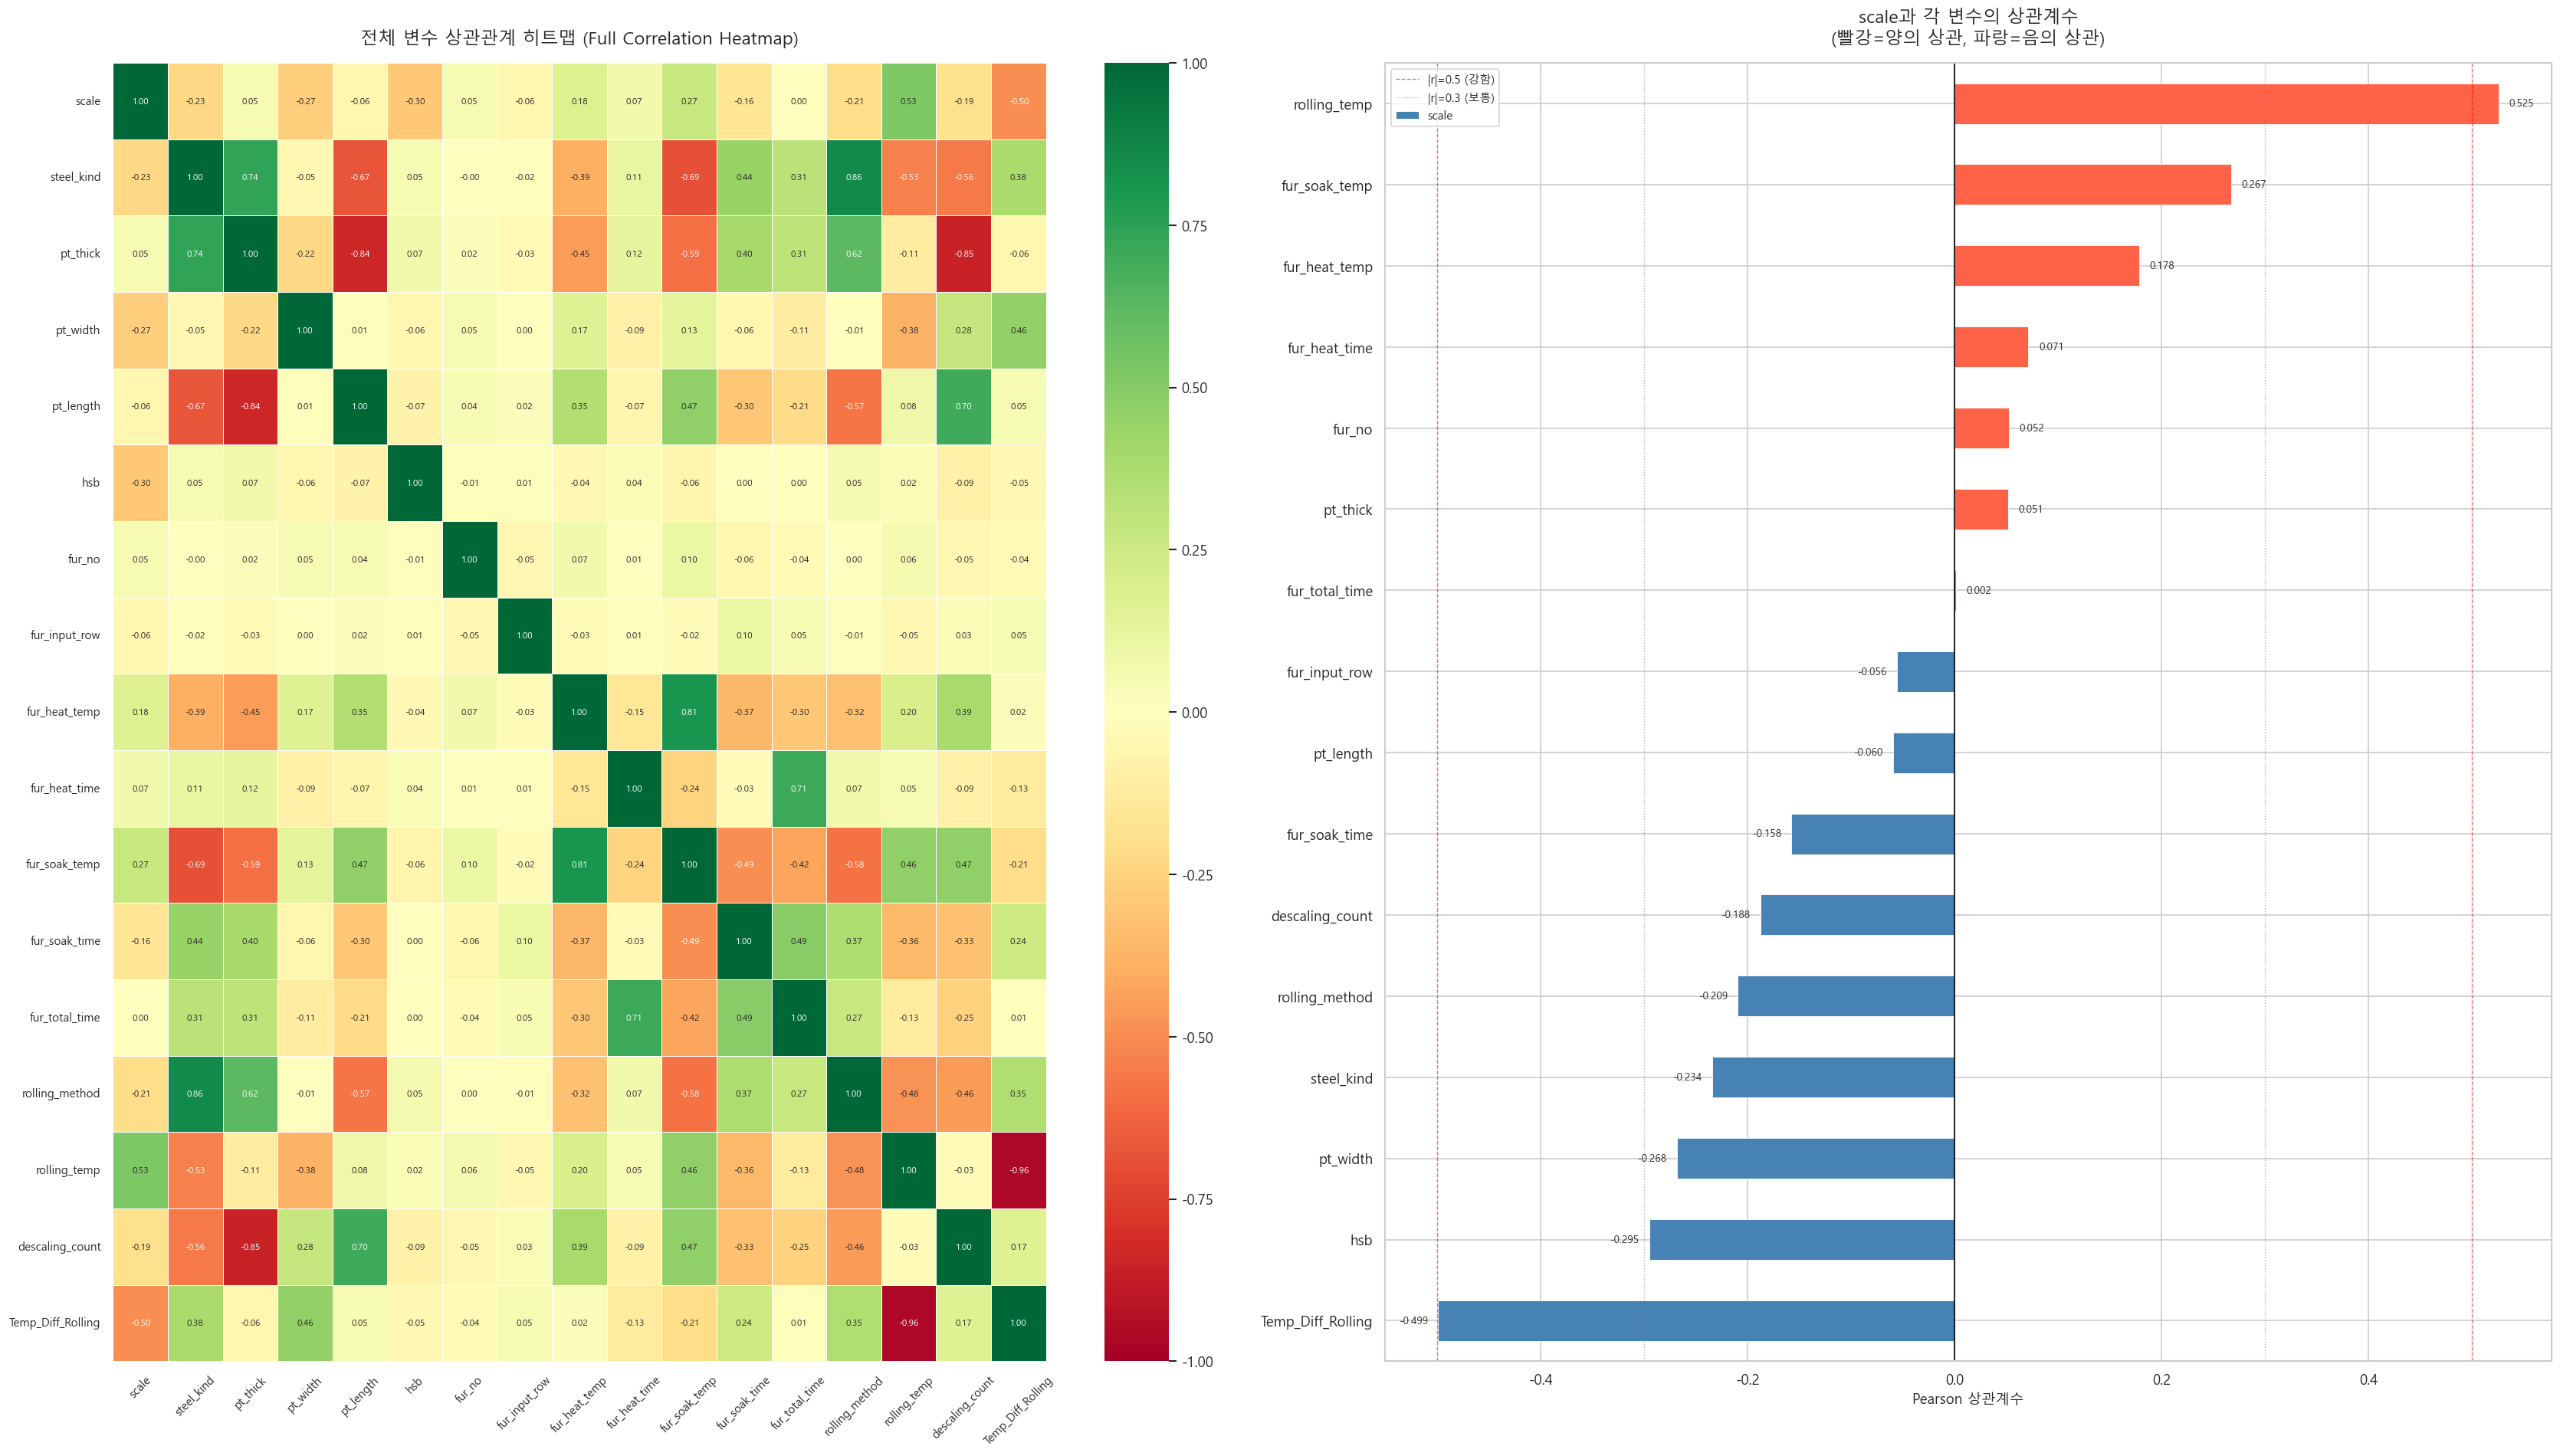

In [ ]:
# 전체 상관관계 히트맵 + Price_log 상관계수 바 차트
fig, axes = plt.subplots(1, 2, figsize=(28, 16))

# [왼쪽] 전체 변수 상관관계 히트맵
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.4, vmin=-1, vmax=1,
    ax=axes[0], annot_kws={'size': 7}
)
axes[0].set_title('전체 변수 상관관계 히트맵 (Full Correlation Heatmap)', fontsize=14, pad=15)
axes[0].tick_params(axis='x', rotation=45, labelsize=9)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)

# [오른쪽] Price_log와의 상관계수 바 차트 (절대값 오름차순으로 수평 출력)
sorted_corr = corr_with_target.sort_values()
bar_colors = ['tomato' if v > 0 else 'steelblue' for v in sorted_corr.values]
sorted_corr.plot(kind='barh', ax=axes[1], color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].axvline(x=0.5, color='red', linewidth=0.8, linestyle='--', alpha=0.6, label='|r|=0.5 (강함)')
axes[1].axvline(x=-0.5, color='red', linewidth=0.8, linestyle='--', alpha=0.6)
axes[1].axvline(x=0.3, color='gray', linewidth=0.8, linestyle=':', alpha=0.6, label='|r|=0.3 (보통)')
axes[1].axvline(x=-0.3, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
axes[1].legend(fontsize=9)
axes[1].set_title('scale과 각 변수의 상관계수\n(빨강=양의 상관, 파랑=음의 상관)', fontsize=14, pad=15)
axes[1].set_xlabel('Pearson 상관계수', fontsize=11)

# 각 막대 끝에 수치 표시
for i, v in enumerate(sorted_corr.values):
    offset = 0.01 if v >= 0 else -0.01
    ha = 'left' if v >= 0 else 'right'
    axes[1].text(v + offset, i, f'{v:.3f}', va='center', ha=ha, fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# 로지스틱 회귀분석으로 각 변수의 통계적 유의성 확인 (EDA 보조)
import statsmodels.api as sm

y_full = df['scale']
X_full_all = df.drop(columns=['scale'])

X_logit = sm.add_constant(X_full_all.astype(float))
logit_result = sm.Logit(y_full, X_logit).fit(disp=False, maxiter=500)

print('=== 로지스틱 회귀분석 결과: 변수별 유의성 확인 ===')
print(f'Pseudo R-squared (McFadden): {logit_result.prsquared:.4f}')
print()
summary_df = pd.DataFrame({
    'coef': logit_result.params,
    'p-value': logit_result.pvalues,
    'significant': logit_result.pvalues < 0.05
}).drop('const').sort_values('p-value')
print(summary_df.round(4).to_string())


=== OLS 회귀분석 결과: 최적 조합(Combo C) 통계 검증 ===
R-squared    : 0.4583
Adj R-squared: 0.4479
F-statistic  : 44.16  (p-value: 1.51e-93)

                            OLS Regression Results                            
Dep. Variable:                  scale   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.448
Method:                 Least Squares   F-statistic:                     44.16
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           1.51e-93
Time:                        19:41:13   Log-Likelihood:                -301.37
No. Observations:                 799   AIC:                             634.7
Df Residuals:                     783   BIC:                             709.7
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.

### EDA 분석 결론
로지스틱 회귀를 통한 변수별 유의성 확인 결과, **rolling_temp**, **hsb**, **fur_soak_temp**, **descaling_count** 등이 p<0.05로 통계적으로 유의미한 변수로 확인되었습니다.
이를 바탕으로 **분류 모델링**을 진행하여 불량 여부 예측 및 핵심 인자를 도출합니다.

---
## Step 1. 데이터 스케일링 및 분할

- **StandardScaler**: 평균 0, 표준편차 1로 변환하여 변수 간 스케일 차이를 제거
- **Train : Test = 7 : 3** 비율로 분할하며 `random_state=1234`로 재현성을 확보


In [ ]:
X_model = df.drop(columns=['scale']).astype(float)
y_model = df['scale']

# StandardScaler: 모든 변수를 평균=0, 표준편차=1로 변환
scaler = StandardScaler()
X_scaled_arr = scaler.fit_transform(X_model)
# X_scaled = pd.DataFrame(X_scaled_arr, columns=final_features, index=X_model.index)
X_scaled = pd.DataFrame(X_scaled_arr, columns=X_model.columns, index=X_model.index)


# Train/Test 7:3 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_model, test_size=0.3, random_state=1234
)

print('=== 스케일링 및 데이터 분할 완료 ===')
print(f'Train X shape: {X_train.shape}  |  Test X shape: {X_test.shape}')
print(f'Train Y shape: {y_train.shape}  |  Test Y shape: {y_test.shape}')
print(f'\n스케일링 후 각 변수의 평균(Train 기준):')
print(X_train.mean().round(4))
print(f'\n스케일링 후 각 변수의 표준편차(Train 기준):')
print(X_train.std().round(4))

# 변수명 저장 (트리 모델 feature importance에 사용)
v_feature_name = X_train.columns


=== 스케일링 및 데이터 분할 완료 ===
Train X shape: (559, 16)  |  Test X shape: (240, 16)
Train Y shape: (559,)  |  Test Y shape: (240,)

스케일링 후 각 변수의 평균(Train 기준):
steel_kind           0.0075
pt_thick             0.0140
pt_width            -0.0055
pt_length            0.0064
hsb                 -0.0180
fur_no               0.0168
fur_input_row        0.0037
fur_heat_temp        0.0078
fur_heat_time       -0.0020
fur_soak_temp       -0.0028
fur_soak_time       -0.0431
fur_total_time      -0.0130
rolling_method      -0.0022
rolling_temp        -0.0051
descaling_count     -0.0122
Temp_Diff_Rolling    0.0047
dtype: float64

스케일링 후 각 변수의 표준편차(Train 기준):
steel_kind           1.0089
pt_thick             1.0251
pt_width             0.9931
pt_length            1.0257
hsb                  1.0389
fur_no               1.0078
fur_input_row        1.0009
fur_heat_temp        1.0263
fur_heat_time        0.9986
fur_soak_temp        1.0277
fur_soak_time        0.9814
fur_total_time       1.0021
rolling_method    

---
## Step 2. 머신러닝 모델링 (분류)

---
### 2-1. 로지스틱 회귀분석 (Logistic Regression)

이진 분류의 기본 모델로, 각 변수의 회귀계수와 p-value를 통해 통계적 유의성을 확인하고  
**Confusion Matrix**와 **ROC Curve**로 분류 성능을 평가한다.

In [ ]:
# 로지스틱 회귀분석
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

logit_clf = LogisticRegression(max_iter=1000, random_state=1234, class_weight='balanced')
logit_clf.fit(X_train, y_train)

y_pred_logit  = logit_clf.predict(X_test)
y_prob_logit  = logit_clf.predict_proba(X_test)[:, 1]

print('--- 로지스틱 회귀 최종 모델 ---')
print(f'AUC  (Test) : {roc_auc_score(y_test, y_prob_logit):.4f}')
print(f'Accuracy    : {accuracy_score(y_test, y_pred_logit):.4f}')
print(f'F1-score    : {f1_score(y_test, y_pred_logit):.4f}')
print()
print(classification_report(y_test, y_pred_logit, target_names=['양품','불량']))

fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_logit),
                       display_labels=['양품','불량']).plot(ax=ax, colorbar=False)
ax.set_title('로지스틱 회귀 - Confusion Matrix')
plt.tight_layout()
plt.show()


                            OLS Regression Results                            
Dep. Variable:                  scale   R-squared:                       0.467
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     31.71
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           1.85e-64
Time:                        19:41:13   Log-Likelihood:                -206.29
No. Observations:                 559   AIC:                             444.6
Df Residuals:                     543   BIC:                             513.8
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.3557      0.01

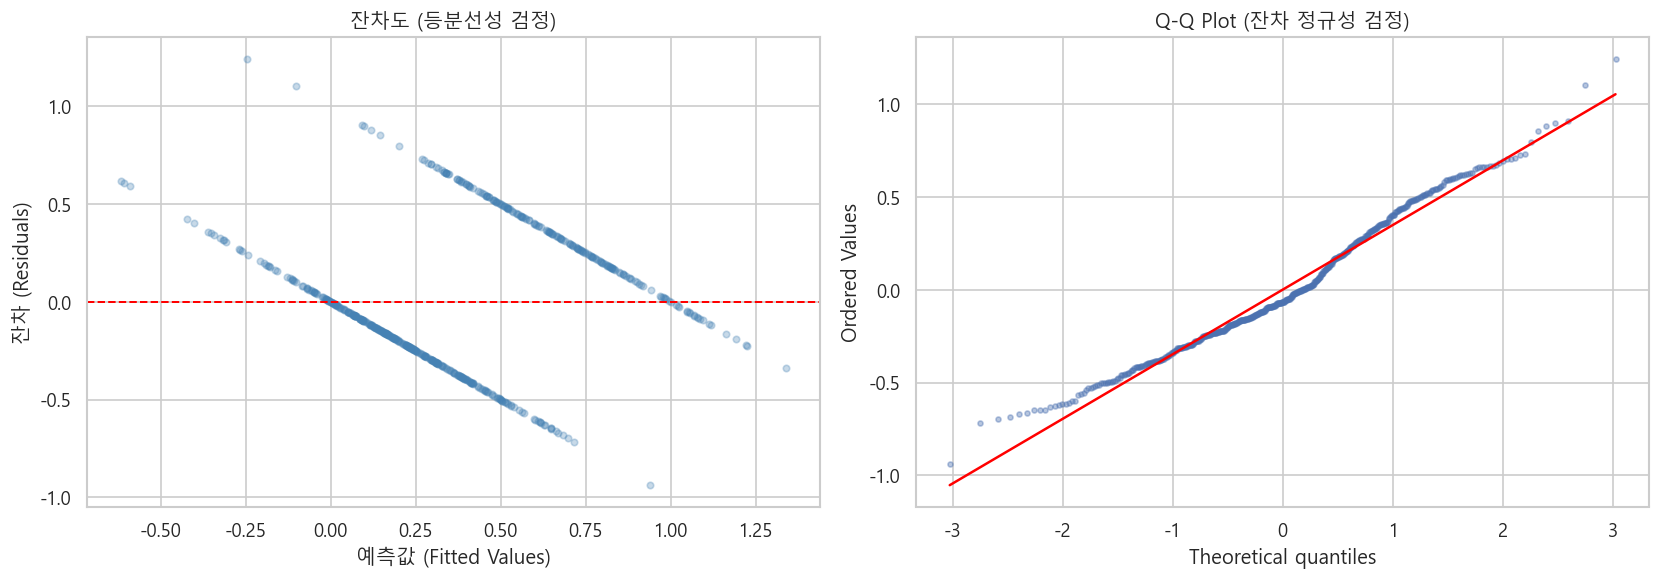

--- OLS 최종 성능 ---
Score on training set: 0.467
Score on test set: 0.428


In [ ]:
# ROC Curve 시각화
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob_logit)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('로지스틱 회귀 - ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'--- 로지스틱 회귀 성능 요약 ---')
print(f'Train Accuracy: {accuracy_score(y_train, logit_clf.predict(X_train)):.4f}')
print(f'Test  Accuracy: {accuracy_score(y_test,  y_pred_logit):.4f}')
print(f'Test  AUC     : {roc_auc:.4f}')


로지스틱 회귀는 선형 결정 경계를 가정하는 모델로, 공정 데이터의 비선형 패턴을 충분히 포착하지 못할 수 있습니다.
이를 보완하기 위해 **비선형 분류 모델(Decision Tree, 앙상블)**로 확장합니다.

---
### 2-2. 의사결정 트리 (Decision Tree Classifier)

파라미터별 AUC 변화를 꺾은선 그래프로 확인한 후 GridSearchCV로 최적 파라미터를 탐색

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

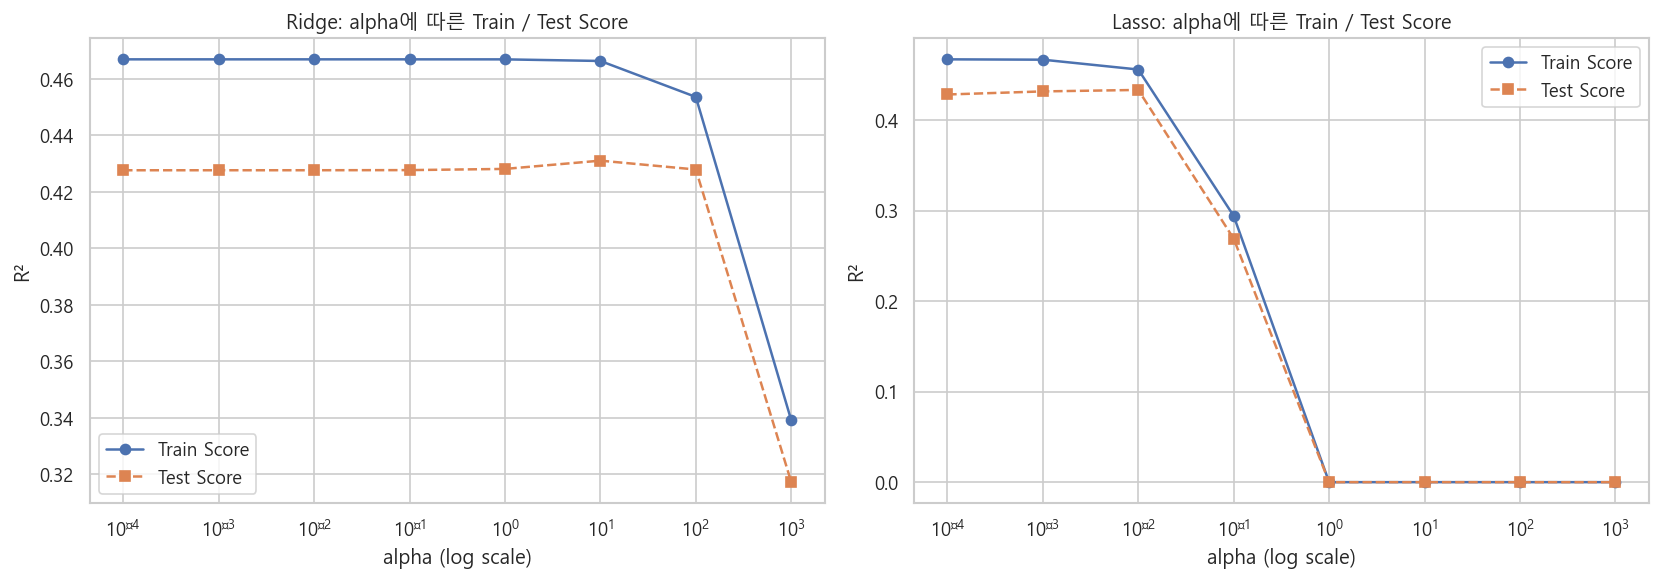

In [ ]:
# 기본 모델: 제약 없이 성장시켜 과적합 기준점 확인
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

tree_uncustomized_clf = DecisionTreeClassifier(random_state=1234)
tree_uncustomized_clf.fit(X_train, y_train)

y_prob_tree_base = tree_uncustomized_clf.predict_proba(X_test)[:,1]
print('--- Decision Tree 기본 모델 ---')
print(f'AUC  Train: {roc_auc_score(y_train, tree_uncustomized_clf.predict_proba(X_train)[:,1]):.4f}')
print(f'AUC  Test : {roc_auc_score(y_test,  y_prob_tree_base):.4f}')
print(f'Acc  Train: {accuracy_score(y_train, tree_uncustomized_clf.predict(X_train)):.4f}')
print(f'Acc  Test : {accuracy_score(y_test,  tree_uncustomized_clf.predict(X_test)):.4f}')


In [ ]:
# 파라미터별 AUC 변화 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Decision Tree: 파라미터별 Train/Test AUC 변화', fontsize=13)

# [1] min_samples_leaf
para_leaf = list(range(1, 31))
train_s, test_s = [], []
for v in para_leaf:
    m = DecisionTreeClassifier(random_state=1234, min_samples_leaf=v)
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[0].plot(para_leaf, train_s, label='Train AUC')
axes[0].plot(para_leaf, test_s,  label='Test AUC')
axes[0].set_xlabel('min_samples_leaf'); axes[0].set_ylabel('AUC')
axes[0].set_title('min_samples_leaf'); axes[0].legend()

# [2] max_depth
para_depth = list(range(1, 21))
train_s, test_s = [], []
for v in para_depth:
    m = DecisionTreeClassifier(random_state=1234, max_depth=v)
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[1].plot(para_depth, train_s, label='Train AUC')
axes[1].plot(para_depth, test_s,  label='Test AUC')
axes[1].set_xlabel('max_depth'); axes[1].set_title('max_depth'); axes[1].legend()

# [3] min_samples_split
para_split = list(range(2, 31))
train_s, test_s = [], []
for v in para_split:
    m = DecisionTreeClassifier(random_state=1234, min_samples_split=v)
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[2].plot(para_split, train_s, label='Train AUC')
axes[2].plot(para_split, test_s,  label='Test AUC')
axes[2].set_xlabel('min_samples_split'); axes[2].set_title('min_samples_split'); axes[2].legend()

plt.tight_layout(); plt.show()


Ridge 최적 alpha: 10
Lasso 최적 alpha: 0.01


In [ ]:
# GridSearchCV: 최적 파라미터 탐색
param_grid_tree_clf = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10],
    'min_samples_split': [5, 10, 15, 20, 30],
    'min_samples_leaf': [3, 5, 8, 10, 15],
}

grid_tree_clf = GridSearchCV(
    DecisionTreeClassifier(random_state=1234),
    param_grid_tree_clf, scoring='roc_auc', cv=5, n_jobs=-1
)
grid_tree_clf.fit(X_train, y_train)
tree_final = grid_tree_clf.best_estimator_

y_pred_tree  = tree_final.predict(X_test)
y_prob_tree  = tree_final.predict_proba(X_test)[:,1]

print('--- GridSearchCV 결과 ---')
print(f'best parameter: {grid_tree_clf.best_params_}')
print(f'best CV AUC  : {grid_tree_clf.best_score_:.4f}')
print(f'\n--- Decision Tree 최종 모델 ---')
print(f'AUC  Train: {roc_auc_score(y_train, tree_final.predict_proba(X_train)[:,1]):.4f}')
print(f'AUC  Test : {roc_auc_score(y_test,  y_prob_tree):.4f}')
print(f'Acc  Train: {accuracy_score(y_train, tree_final.predict(X_train)):.4f}')
print(f'Acc  Test : {accuracy_score(y_test,  y_pred_tree):.4f}')
print(f'F1   Test : {f1_score(y_test, y_pred_tree):.4f}')



--- Ridge 최종 모델 ---
Score on training set: 0.466
Score on test set: 0.431

--- Lasso 최종 모델 ---
Score on training set: 0.456
Score on test set: 0.433

--- Lasso 계수 (0이면 자동 제거됨) ---
            Feature  Coefficient
13     rolling_temp     0.177812
4               hsb    -0.145890
14  descaling_count    -0.106608
7     fur_heat_temp     0.076513
0        steel_kind    -0.058396
2          pt_width    -0.045215
3         pt_length    -0.035205
8     fur_heat_time     0.026805


GridSearchCV를 통해 최적 파라미터를 선정하였으며, AUC 기준으로 모델 성능을 비교합니다.
단일 트리의 한계를 보완하기 위해 **앙상블 기법(Random Forest)**으로 확장합니다.

---
### 2-3. Random Forest Classifier

다수의 Decision Tree를 앙상블하여 과적합을 줄이고 일반화 성능을 높임.
파라미터별 AUC 변화 탐색 후 GridSearchCV로 최적 조합을 확정함.

In [ ]:
# 기본 모델: 과적합 기준점 확인
from sklearn.ensemble import RandomForestClassifier

rf_uncustomized = RandomForestClassifier(random_state=1234, n_jobs=-1)
rf_uncustomized.fit(X_train, y_train)
print('--- Random Forest 기본 모델 ---')
print(f'AUC  Train: {roc_auc_score(y_train, rf_uncustomized.predict_proba(X_train)[:,1]):.4f}')
print(f'AUC  Test : {roc_auc_score(y_test,  rf_uncustomized.predict_proba(X_test)[:,1]):.4f}')
print(f'Acc  Train: {accuracy_score(y_train, rf_uncustomized.predict(X_train)):.4f}')
print(f'Acc  Test : {accuracy_score(y_test,  rf_uncustomized.predict(X_test)):.4f}')


--- Decision Tree 기본 모델 ---
Score on training set: 1.000
Score on test set: 0.982


NameError: name 'RandomForestClassifier' is not defined

c:\Users\Owner\anaconda3\envs\bigdata\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from current font.
  func(*args, **kwargs)
c:\Users\Owner\anaconda3\envs\bigdata\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from current font.
  func(*args, **kwargs)
c:\Users\Owner\anaconda3\envs\bigdata\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from current font.
  func(*args, **kwargs)
c:\Users\Owner\anaconda3\envs\bigdata\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from current font.
  func(*args, **kwargs)
c:\Users\Owner\anaconda3\envs\bigdata\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from current font.
  func(*args, **kwargs)
c:\Users\Owner\anaconda3\envs\bigdata\lib\site-packages\IPython\core\events.

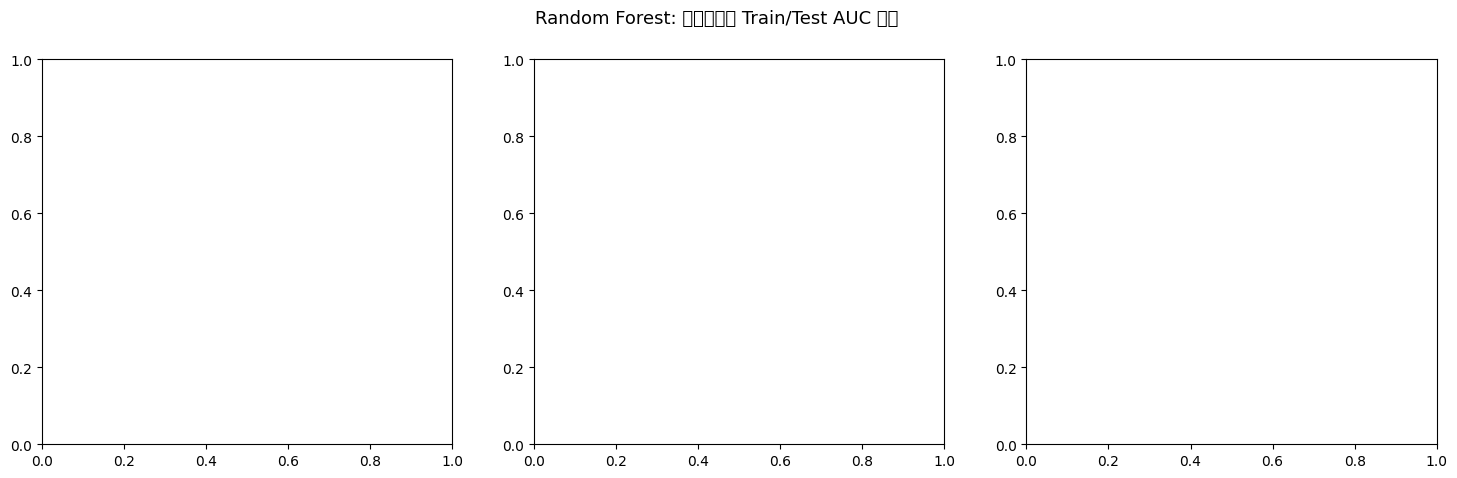

In [ ]:
import matplotlib.pyplot as plt
# 파라미터별 AUC 변화 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Random Forest: 파라미터별 Train/Test AUC 변화', fontsize=13)

# [1] min_samples_leaf
para_leaf = list(range(1, 21))
train_s, test_s = [], []
for v in para_leaf:
    m = RandomForestClassifier(random_state=1234, n_estimators=100, min_samples_leaf=v, n_jobs=-1)
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[0].plot(para_leaf, train_s, label='Train AUC')
axes[0].plot(para_leaf, test_s,  label='Test AUC')
axes[0].set_xlabel('min_samples_leaf'); axes[0].set_ylabel('AUC')
axes[0].set_title('min_samples_leaf'); axes[0].legend()

# [2] max_depth
para_depth = list(range(1, 21))
train_s, test_s = [], []
for v in para_depth:
    m = RandomForestClassifier(random_state=1234, n_estimators=100, max_depth=v, n_jobs=-1)
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[1].plot(para_depth, train_s, label='Train AUC')
axes[1].plot(para_depth, test_s,  label='Test AUC')
axes[1].set_xlabel('max_depth'); axes[1].set_title('max_depth'); axes[1].legend()

# [3] n_estimators
para_n = [10, 30, 50, 100, 150, 200]
train_s, test_s = [], []
for v in para_n:
    m = RandomForestClassifier(random_state=1234, n_estimators=v, n_jobs=-1)
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[2].plot(para_n, train_s, label='Train AUC')
axes[2].plot(para_n, test_s,  label='Test AUC')
axes[2].set_xlabel('n_estimators'); axes[2].set_title('n_estimators'); axes[2].legend()

plt.tight_layout(); plt.show()


In [ ]:
# GridSearchCV: 최적 파라미터 탐색
param_grid_rf = {
    'max_depth': [4, 5, 6, 7, 8],
    'min_samples_split': [5, 10, 15, 20],
    'min_samples_leaf': [3, 5, 8, 10],
    'n_estimators': [100],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=1234, n_jobs=-1),
    param_grid_rf, scoring='roc_auc', cv=5, n_jobs=-1
)
grid_rf.fit(X_train, y_train)
rf_final = grid_rf.best_estimator_

y_pred_rf = rf_final.predict(X_test)
y_prob_rf = rf_final.predict_proba(X_test)[:,1]

print('--- GridSearchCV 결과 ---')
print(f'best parameter: {grid_rf.best_params_}')
print(f'best CV AUC  : {grid_rf.best_score_:.4f}')
print(f'\n--- Random Forest 최종 모델 ---')
print(f'AUC  Train: {roc_auc_score(y_train, rf_final.predict_proba(X_train)[:,1]):.4f}')
print(f'AUC  Test : {roc_auc_score(y_test,  y_prob_rf):.4f}')
print(f'Acc  Train: {accuracy_score(y_train, rf_final.predict(X_train)):.4f}')
print(f'Acc  Test : {accuracy_score(y_test,  y_pred_rf):.4f}')
print(f'F1   Test : {f1_score(y_test, y_pred_rf):.4f}')

v_feature_name = X_train.columns.tolist()


--- GridSearchCV 결과 ---
best parameter: {'max_depth': 7, 'min_samples_leaf': 3, 'min_samples_split': 5}
best CV score: 0.957

--- Decision Tree 최종 모델 ---
Score on training set: 0.985
Score on test set: 0.999


--- Decision Tree 변수 중요도 ---
          Feature  Importance
     rolling_temp      0.5356
              hsb      0.1663
    fur_soak_temp      0.1634
         pt_thick      0.0774
  descaling_count      0.0573
       steel_kind      0.0000
         pt_width      0.0000
        pt_length      0.0000
           fur_no      0.0000
    fur_input_row      0.0000
    fur_heat_temp      0.0000
    fur_heat_time      0.0000
    fur_soak_time      0.0000
   fur_total_time      0.0000
   rolling_method      0.0000
Temp_Diff_Rolling      0.0000


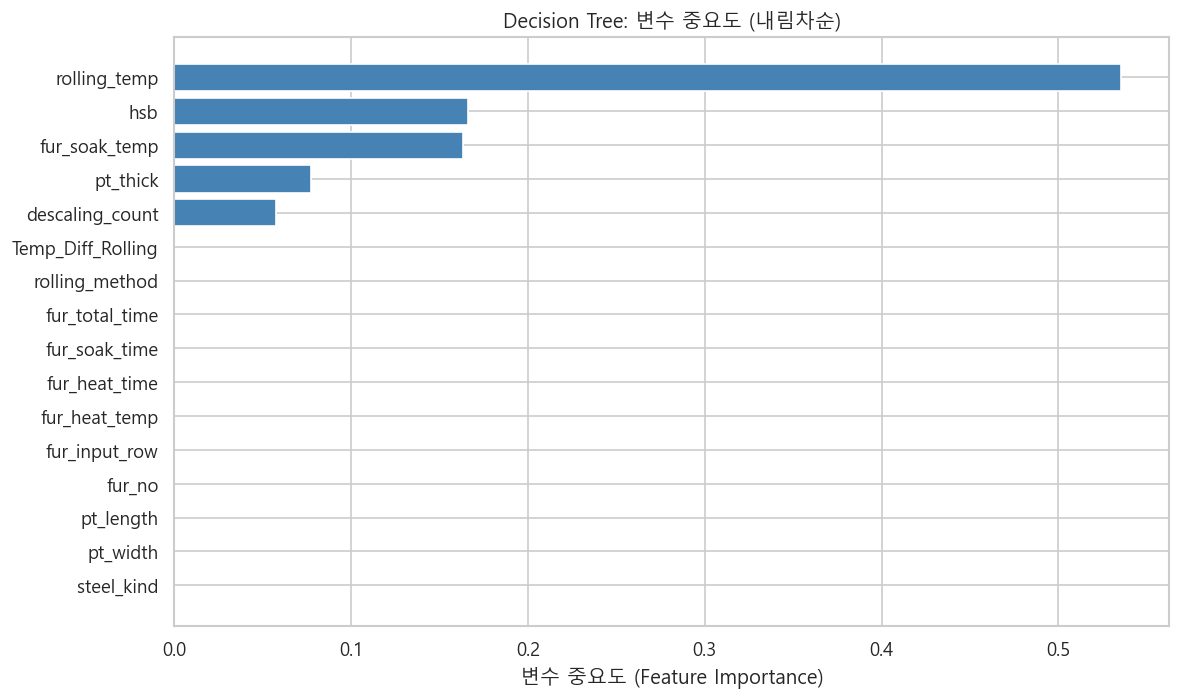

In [ ]:
# Random Forest 변수 중요도 시각화
df_imp_rf = pd.DataFrame({'Feature': v_feature_name, 'Importance': rf_final.feature_importances_})
df_imp_rf.sort_values('Importance', ascending=False, inplace=True)
print('--- Random Forest 변수 중요도 ---')
print(df_imp_rf.round(4).to_string(index=False))

df_imp_rf.sort_values('Importance', ascending=True, inplace=True)
coordinates = range(len(df_imp_rf))
plt.figure(figsize=(10, 6))
plt.barh(y=coordinates, width=df_imp_rf['Importance'], color='tomato')
plt.yticks(coordinates, df_imp_rf['Feature'])
plt.title('Random Forest - 변수 중요도')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()


**핵심 인자:** rolling_temp가 가장 높은 중요도를 기록하며 스케일 발생의 핵심 지배 인자임을 확인.
앙상블을 통해 단일 트리 대비 일반화 성능이 향상되었으며, 이후 **Gradient Boosting** 계열로 성능을 더욱 고도화합니다.

---
### 2-4. Gradient Boosting Classifier

이전 트리의 오차(잔차)를 순차적으로 학습하는 앙상블 방법.
`max_depth`, `min_samples_leaf/split`, `learning_rate`, `n_estimators`를 탐색한다.

In [ ]:
# 기본 모델: 과적합 기준점 확인
from sklearn.ensemble import GradientBoostingClassifier

gb_uncustomized = GradientBoostingClassifier(random_state=1234)
gb_uncustomized.fit(X_train, y_train)
print('--- Gradient Boosting 기본 모델 ---')
print(f'AUC  Train: {roc_auc_score(y_train, gb_uncustomized.predict_proba(X_train)[:,1]):.4f}')
print(f'AUC  Test : {roc_auc_score(y_test,  gb_uncustomized.predict_proba(X_test)[:,1]):.4f}')
print(f'Acc  Train: {accuracy_score(y_train, gb_uncustomized.predict(X_train)):.4f}')
print(f'Acc  Test : {accuracy_score(y_test,  gb_uncustomized.predict(X_test)):.4f}')


--- Random Forest 기본 모델 ---
Score on training set: 0.994
Score on test set: 0.963


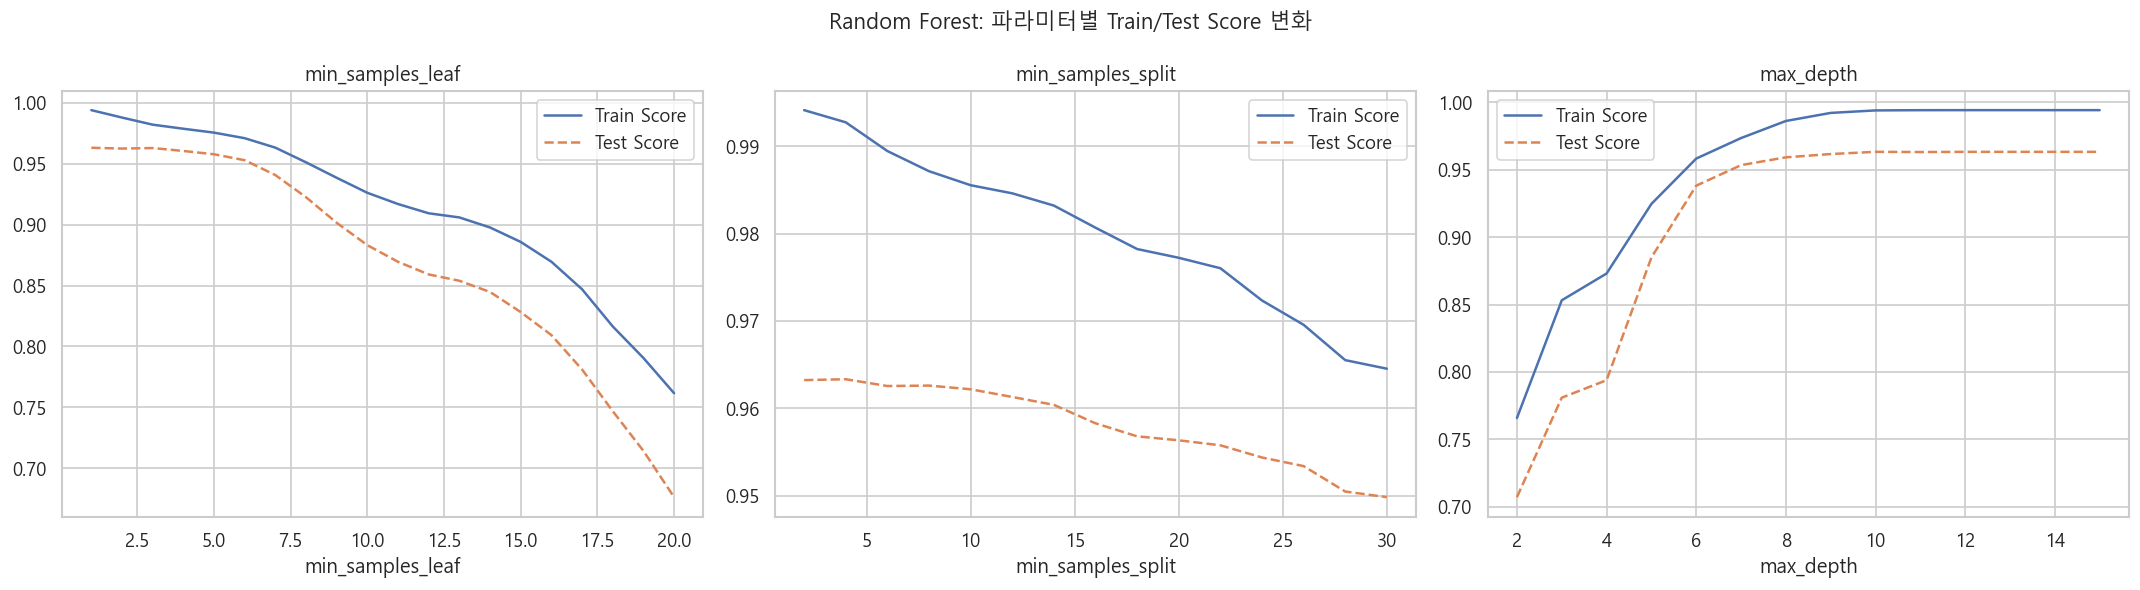

In [ ]:
# 파라미터별 AUC 변화 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Gradient Boosting: 파라미터별 Train/Test AUC 변화', fontsize=13)

para_leaf = list(range(1, 21))
train_s, test_s = [], []
for v in para_leaf:
    m = GradientBoostingClassifier(random_state=1234, n_estimators=100, min_samples_leaf=v)
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[0].plot(para_leaf, train_s, label='Train AUC')
axes[0].plot(para_leaf, test_s,  label='Test AUC')
axes[0].set_xlabel('min_samples_leaf'); axes[0].set_title('min_samples_leaf'); axes[0].legend()

para_depth = list(range(1, 11))
train_s, test_s = [], []
for v in para_depth:
    m = GradientBoostingClassifier(random_state=1234, n_estimators=100, max_depth=v)
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[1].plot(para_depth, train_s, label='Train AUC')
axes[1].plot(para_depth, test_s,  label='Test AUC')
axes[1].set_xlabel('max_depth'); axes[1].set_title('max_depth'); axes[1].legend()

para_lr = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
train_s, test_s = [], []
for v in para_lr:
    m = GradientBoostingClassifier(random_state=1234, n_estimators=100, learning_rate=v)
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[2].semilogx(para_lr, train_s, label='Train AUC')
axes[2].semilogx(para_lr, test_s,  label='Test AUC')
axes[2].set_xlabel('learning_rate'); axes[2].set_title('learning_rate'); axes[2].legend()

plt.tight_layout(); plt.show()


**파라미터 전략:** AUC 기준으로 Train/Test 균형이 가장 안정적인 지점을 시각적으로 확인한 뒤 GridSearchCV로 최적 조합을 확정함.

In [ ]:
# GridSearchCV: 최적 파라미터 탐색
param_grid_gb = {
    'n_estimators':    [50, 100, 200],
    'learning_rate':   [0.05, 0.1, 0.2],
    'max_depth':       [3, 4, 5],
    'min_samples_leaf': [5, 10, 15],
    'min_samples_split': [10, 20],
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=1234),
    param_grid_gb, scoring='roc_auc', cv=5, n_jobs=-1
)
grid_gb.fit(X_train, y_train)
gb_final = grid_gb.best_estimator_

y_pred_gb = gb_final.predict(X_test)
y_prob_gb = gb_final.predict_proba(X_test)[:,1]

print('--- GridSearchCV 결과 ---')
print(f'best parameter: {grid_gb.best_params_}')
print(f'best CV AUC  : {grid_gb.best_score_:.4f}')
print(f'\n--- Gradient Boosting 최종 모델 ---')
print(f'AUC  Train: {roc_auc_score(y_train, gb_final.predict_proba(X_train)[:,1]):.4f}')
print(f'AUC  Test : {roc_auc_score(y_test,  y_prob_gb):.4f}')
print(f'Acc  Train: {accuracy_score(y_train, gb_final.predict(X_train)):.4f}')
print(f'Acc  Test : {accuracy_score(y_test,  y_pred_gb):.4f}')
print(f'F1   Test : {f1_score(y_test, y_pred_gb):.4f}')


--- GridSearchCV 결과 ---
best parameter: {'max_depth': 8, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 100}
best CV score: 0.938

--- Random Forest 최종 모델 ---
Score on training set: 0.981
Score on test set: 0.963


--- Random Forest 변수 중요도 ---
          Feature  Importance
     rolling_temp      0.5381
    fur_soak_temp      0.1676
              hsb      0.1557
  descaling_count      0.0607
         pt_thick      0.0401
Temp_Diff_Rolling      0.0146
        pt_length      0.0107
    fur_soak_time      0.0038
   fur_total_time      0.0036
    fur_heat_temp      0.0017
    fur_heat_time      0.0015
         pt_width      0.0007
       steel_kind      0.0006
           fur_no      0.0004
    fur_input_row      0.0003
   rolling_method      0.0000


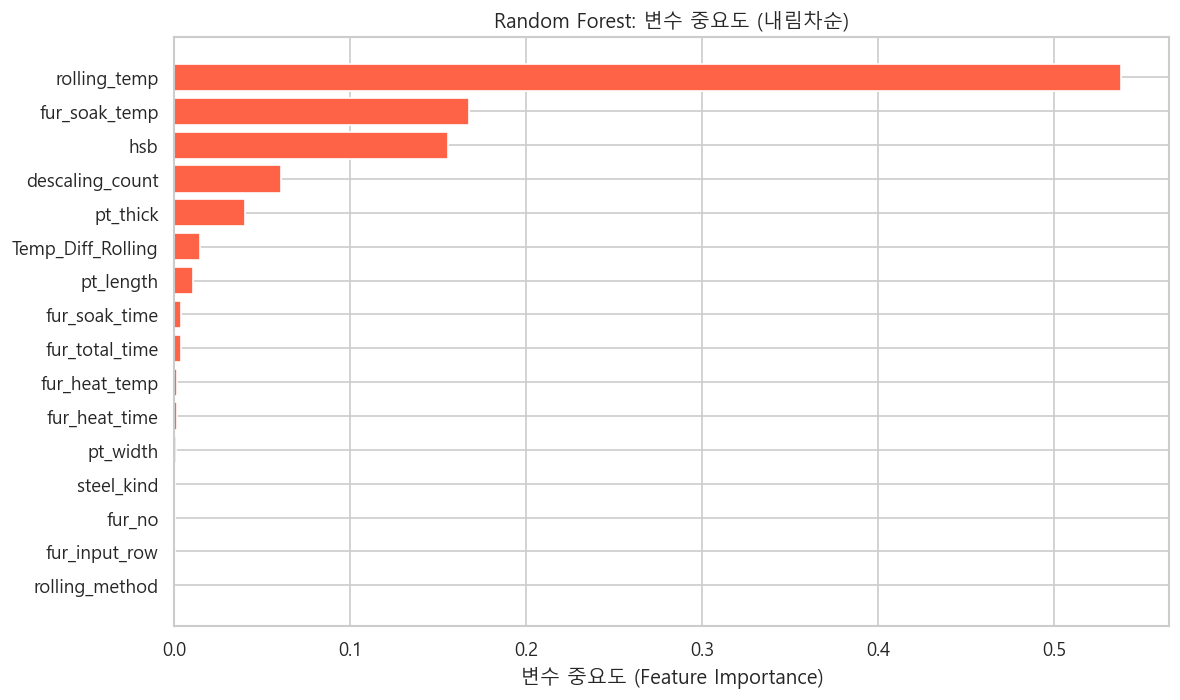

In [ ]:
# Gradient Boosting 변수 중요도 시각화
df_imp_gb = pd.DataFrame({'Feature': v_feature_name, 'Importance': gb_final.feature_importances_})
df_imp_gb.sort_values('Importance', ascending=False, inplace=True)
print('--- Gradient Boosting 변수 중요도 ---')
print(df_imp_gb.round(4).to_string(index=False))

df_imp_gb.sort_values('Importance', ascending=True, inplace=True)
coordinates = range(len(df_imp_gb))
plt.figure(figsize=(10, 6))
plt.barh(y=coordinates, width=df_imp_gb['Importance'], color='seagreen')
plt.yticks(coordinates, df_imp_gb['Feature'])
plt.title('Gradient Boosting - 변수 중요도')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()


**Gradient Boosting 결과:** 분류 AUC 기준으로 우수한 성능을 보이며, rolling_temp·fur_soak_temp·hsb가 공통 상위 변수로 확인되었습니다.
Train/Test AUC 균형이 가장 안정적인 모델 중 하나입니다.

---
### 2-5. XGBoost Classifier

Gradient Boosting을 병렬 처리에 최적화한 고성능 부스팅 알고리즘.
`learning_rate`, `n_estimators`, `max_depth`, `subsample`, `colsample_bytree`를 탐색한다.

In [ ]:
from xgboost import XGBClassifier

xgb_uncustomized = XGBClassifier(random_state=1234, n_jobs=-1, verbosity=0, use_label_encoder=False, eval_metric='logloss')
xgb_uncustomized.fit(X_train, y_train)
print('--- XGBoost 기본 모델 ---')
print(f'AUC  Train: {roc_auc_score(y_train, xgb_uncustomized.predict_proba(X_train)[:,1]):.4f}')
print(f'AUC  Test : {roc_auc_score(y_test,  xgb_uncustomized.predict_proba(X_test)[:,1]):.4f}')
print(f'Acc  Train: {accuracy_score(y_train, xgb_uncustomized.predict(X_train)):.4f}')
print(f'Acc  Test : {accuracy_score(y_test,  xgb_uncustomized.predict(X_test)):.4f}')


--- Gradient Boosting 기본 모델 ---
Score on training set: 0.993
Score on test set: 0.937


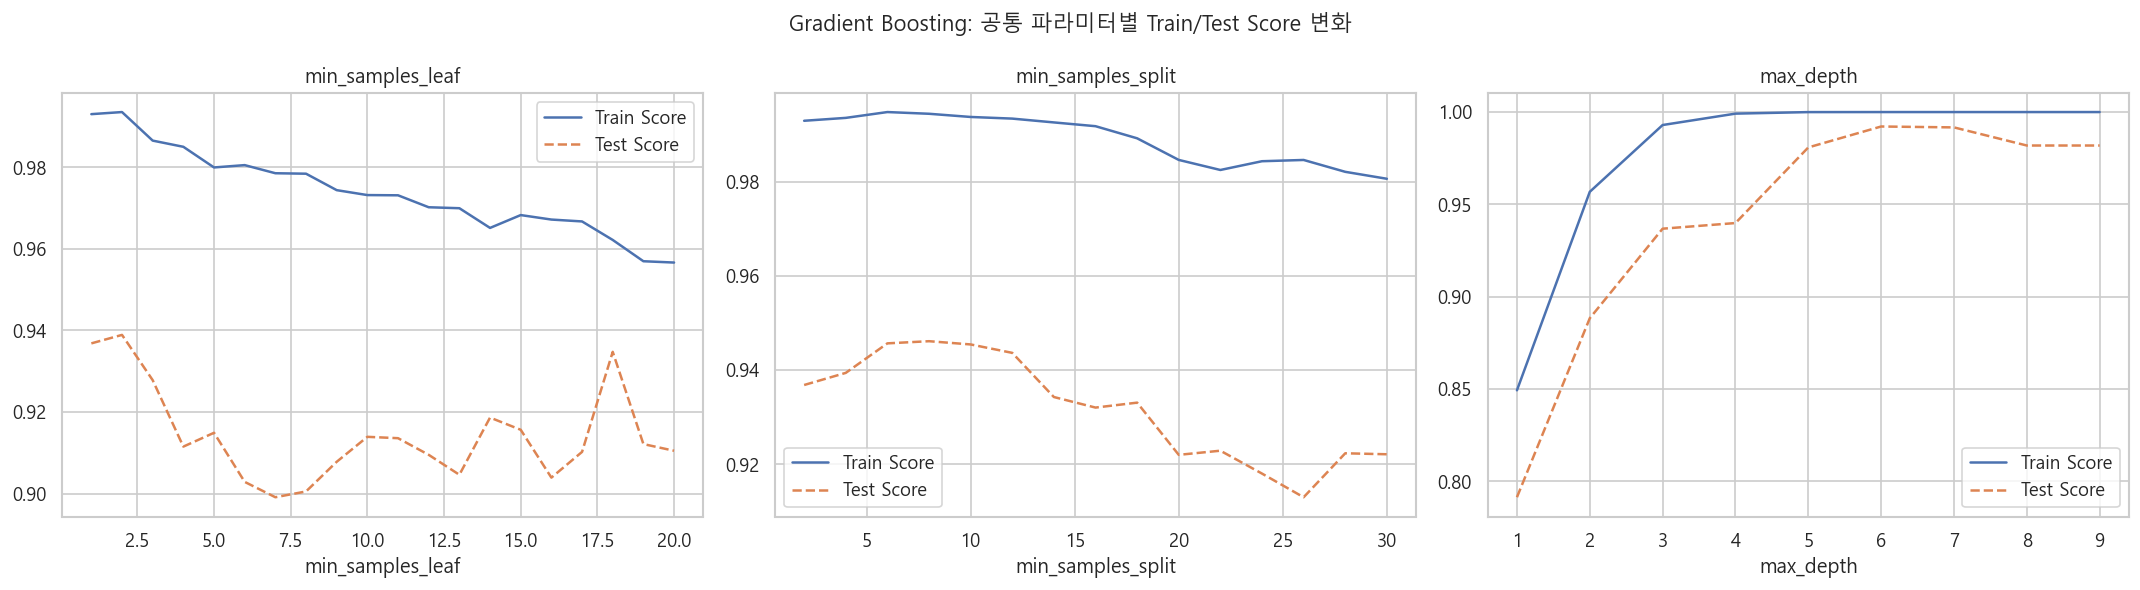

In [ ]:
# 파라미터별 AUC 변화 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('XGBoost: 파라미터별 Train/Test AUC 변화', fontsize=13)

para_depth = list(range(1, 11))
train_s, test_s = [], []
for v in para_depth:
    m = XGBClassifier(random_state=1234, n_estimators=100, max_depth=v, n_jobs=-1, verbosity=0, eval_metric='logloss')
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[0].plot(para_depth, train_s, label='Train AUC')
axes[0].plot(para_depth, test_s,  label='Test AUC')
axes[0].set_xlabel('max_depth'); axes[0].set_title('max_depth'); axes[0].legend()

para_lr = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
train_s, test_s = [], []
for v in para_lr:
    m = XGBClassifier(random_state=1234, n_estimators=100, learning_rate=v, n_jobs=-1, verbosity=0, eval_metric='logloss')
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[1].semilogx(para_lr, train_s, label='Train AUC')
axes[1].semilogx(para_lr, test_s,  label='Test AUC')
axes[1].set_xlabel('learning_rate'); axes[1].set_title('learning_rate'); axes[1].legend()

para_n = [50, 100, 200, 300]
train_s, test_s = [], []
for v in para_n:
    m = XGBClassifier(random_state=1234, n_estimators=v, n_jobs=-1, verbosity=0, eval_metric='logloss')
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[2].plot(para_n, train_s, label='Train AUC')
axes[2].plot(para_n, test_s,  label='Test AUC')
axes[2].set_xlabel('n_estimators'); axes[2].set_title('n_estimators'); axes[2].legend()

plt.tight_layout(); plt.show()


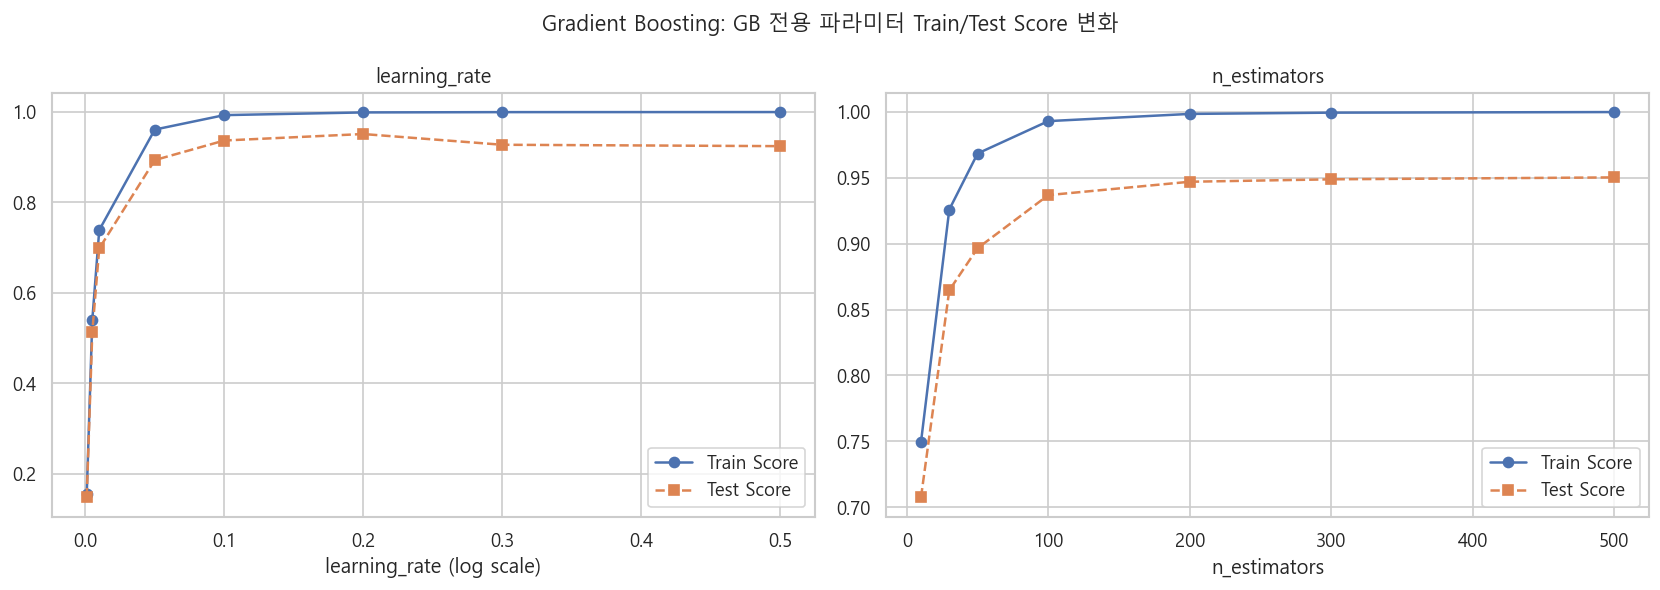

In [ ]:
# GridSearchCV: 최적 파라미터 탐색
param_grid_xgb = {
    'n_estimators':    [100, 200, 300],
    'learning_rate':   [0.05, 0.1, 0.2],
    'max_depth':       [3, 4, 5, 6],
    'subsample':       [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=1234, n_jobs=-1, verbosity=0, eval_metric='logloss'),
    param_grid_xgb, scoring='roc_auc', cv=5, n_jobs=-1
)
grid_xgb.fit(X_train, y_train)
xgb_final = grid_xgb.best_estimator_

y_pred_xgb = xgb_final.predict(X_test)
y_prob_xgb = xgb_final.predict_proba(X_test)[:,1]

print('--- GridSearchCV 결과 ---')
print(f'best parameter: {grid_xgb.best_params_}')
print(f'best CV AUC  : {grid_xgb.best_score_:.4f}')
print(f'\n--- XGBoost 최종 모델 ---')
print(f'AUC  Train: {roc_auc_score(y_train, xgb_final.predict_proba(X_train)[:,1]):.4f}')
print(f'AUC  Test : {roc_auc_score(y_test,  y_prob_xgb):.4f}')
print(f'Acc  Train: {accuracy_score(y_train, xgb_final.predict(X_train)):.4f}')
print(f'Acc  Test : {accuracy_score(y_test,  y_pred_xgb):.4f}')
print(f'F1   Test : {f1_score(y_test, y_pred_xgb):.4f}')


In [ ]:
# XGBoost 변수 중요도 시각화
df_imp_xgb = pd.DataFrame({'Feature': v_feature_name, 'Importance': xgb_final.feature_importances_})
df_imp_xgb.sort_values('Importance', ascending=False, inplace=True)
print('--- XGBoost 변수 중요도 ---')
print(df_imp_xgb.round(4).to_string(index=False))

df_imp_xgb.sort_values('Importance', ascending=True, inplace=True)
coordinates = range(len(df_imp_xgb))
plt.figure(figsize=(10, 6))
plt.barh(y=coordinates, width=df_imp_xgb['Importance'], color='darkorange')
plt.yticks(coordinates, df_imp_xgb['Feature'])
plt.title('XGBoost - 변수 중요도')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()


--- GridSearchCV 결과 ---
best parameter: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 20, 'n_estimators': 100}
best CV score: 0.953

--- Gradient Boosting 최종 모델 ---
Score on training set: 0.991
Score on test set: 0.978


**XGBoost 결과:** 병렬 처리로 빠른 학습이 가능하며, AUC 기준 우수한 분류 성능을 보입니다.
Train AUC와 Test AUC 차이가 클 경우 과적합으로 판단하고, GridSearchCV로 선택된 파라미터로 최종 모델을 확정합니다.

---
### 2-6. LightGBM Classifier

리프(Leaf) 중심으로 트리를 성장시켜 XGBoost 대비 학습 속도가 빠른 부스팅 알고리즘.
`num_leaves`, `learning_rate`, `n_estimators`, `min_child_samples`를 탐색함.

In [ ]:
from lightgbm import LGBMClassifier

lgb_uncustomized = LGBMClassifier(random_state=1234, n_jobs=-1, verbose=-1)
lgb_uncustomized.fit(X_train, y_train)
print('--- LightGBM 기본 모델 ---')
print(f'AUC  Train: {roc_auc_score(y_train, lgb_uncustomized.predict_proba(X_train)[:,1]):.4f}')
print(f'AUC  Test : {roc_auc_score(y_test,  lgb_uncustomized.predict_proba(X_test)[:,1]):.4f}')
print(f'Acc  Train: {accuracy_score(y_train, lgb_uncustomized.predict(X_train)):.4f}')
print(f'Acc  Test : {accuracy_score(y_test,  lgb_uncustomized.predict(X_test)):.4f}')


In [ ]:
# 파라미터별 AUC 변화 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('LightGBM: 파라미터별 Train/Test AUC 변화', fontsize=13)

para_leaves = [10, 20, 31, 50, 70, 100, 150, 200]
train_s, test_s = [], []
for v in para_leaves:
    m = LGBMClassifier(random_state=1234, n_estimators=100, num_leaves=v, n_jobs=-1, verbose=-1)
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[0].plot(para_leaves, train_s, label='Train AUC')
axes[0].plot(para_leaves, test_s,  label='Test AUC')
axes[0].set_xlabel('num_leaves'); axes[0].set_title('num_leaves'); axes[0].legend()

para_lr = [0.01, 0.05, 0.1, 0.2, 0.3]
train_s, test_s = [], []
for v in para_lr:
    m = LGBMClassifier(random_state=1234, n_estimators=100, learning_rate=v, n_jobs=-1, verbose=-1)
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[1].semilogx(para_lr, train_s, label='Train AUC')
axes[1].semilogx(para_lr, test_s,  label='Test AUC')
axes[1].set_xlabel('learning_rate'); axes[1].set_title('learning_rate'); axes[1].legend()

para_child = [5, 10, 20, 30, 50]
train_s, test_s = [], []
for v in para_child:
    m = LGBMClassifier(random_state=1234, n_estimators=100, min_child_samples=v, n_jobs=-1, verbose=-1)
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[2].plot(para_child, train_s, label='Train AUC')
axes[2].plot(para_child, test_s,  label='Test AUC')
axes[2].set_xlabel('min_child_samples'); axes[2].set_title('min_child_samples'); axes[2].legend()

plt.tight_layout(); plt.show()


--- XGBoost 기본 모델 ---
Score on training set: 1.000
Score on test set: 0.941


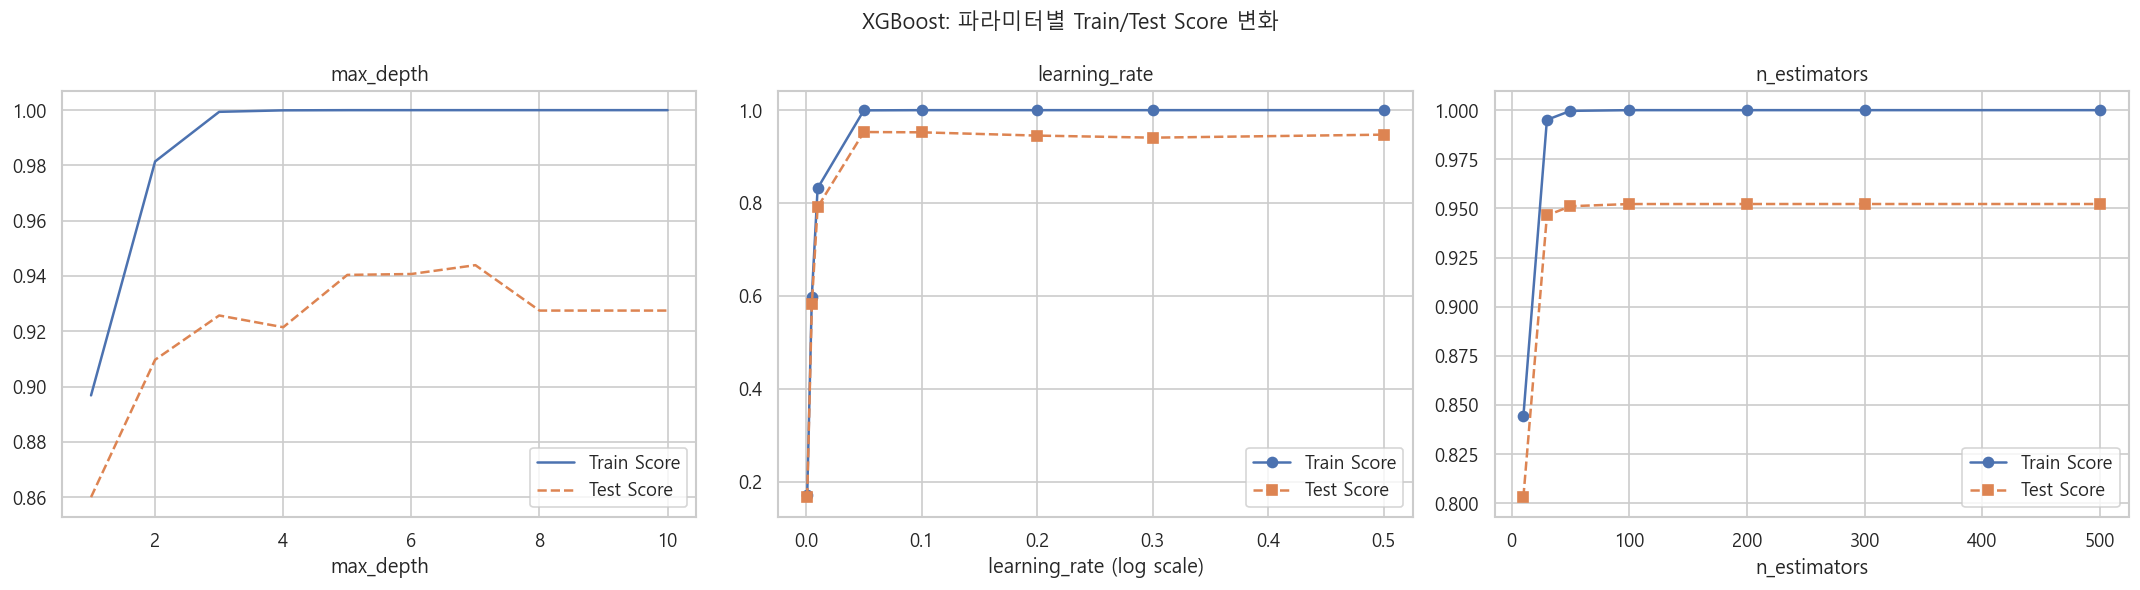

In [ ]:
# GridSearchCV: 최적 파라미터 탐색
param_grid_lgb = {
    'n_estimators':      [100, 200, 300],
    'learning_rate':     [0.05, 0.1, 0.2],
    'num_leaves':        [20, 31, 50, 70],
    'min_child_samples': [10, 20, 30],
}

grid_lgb = GridSearchCV(
    LGBMClassifier(random_state=1234, n_jobs=-1, verbose=-1),
    param_grid_lgb, scoring='roc_auc', cv=5, n_jobs=-1
)
grid_lgb.fit(X_train, y_train)
lgb_final = grid_lgb.best_estimator_

y_pred_lgb = lgb_final.predict(X_test)
y_prob_lgb = lgb_final.predict_proba(X_test)[:,1]

print('--- GridSearchCV 결과 ---')
print(f'best parameter: {grid_lgb.best_params_}')
print(f'best CV AUC  : {grid_lgb.best_score_:.4f}')
print(f'\n--- LightGBM 최종 모델 ---')
print(f'AUC  Train: {roc_auc_score(y_train, lgb_final.predict_proba(X_train)[:,1]):.4f}')
print(f'AUC  Test : {roc_auc_score(y_test,  y_prob_lgb):.4f}')
print(f'Acc  Train: {accuracy_score(y_train, lgb_final.predict(X_train)):.4f}')
print(f'Acc  Test : {accuracy_score(y_test,  y_pred_lgb):.4f}')
print(f'F1   Test : {f1_score(y_test, y_pred_lgb):.4f}')


In [ ]:
# LightGBM 변수 중요도 시각화
df_imp_lgb = pd.DataFrame({'Feature': v_feature_name, 'Importance': lgb_final.feature_importances_})
df_imp_lgb.sort_values('Importance', ascending=False, inplace=True)
print('--- LightGBM 변수 중요도 ---')
print(df_imp_lgb.round(4).to_string(index=False))

df_imp_lgb.sort_values('Importance', ascending=True, inplace=True)
coordinates = range(len(df_imp_lgb))
plt.figure(figsize=(10, 6))
plt.barh(y=coordinates, width=df_imp_lgb['Importance'], color='mediumpurple')
plt.yticks(coordinates, df_imp_lgb['Feature'])
plt.title('LightGBM - 변수 중요도')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()


--- GridSearchCV 결과 ---
best parameter: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
best CV score: 0.970

--- XGBoost 최종 모델 ---
Score on training set: 1.000
Score on test set: 0.930


**LightGBM 결과:** Leaf-wise 성장 특성으로 다양한 변수를 골고루 활용하는 경향이 있으며, 분류 AUC 기준으로 안정적인 성능을 보입니다.

---
### 2-7. Support Vector Machine (SVM / SVC)

마진(Margin)을 최대화하는 초평면을 찾아 **분류**를 수행하는 모델.
`C`, `kernel`을 탐색하며, AUC로 성능을 평가한다.

In [ ]:
from sklearn.svm import SVC

svm_uncustomized = SVC(probability=True, random_state=1234)
svm_uncustomized.fit(X_train, y_train)
print('--- SVC 기본 모델 ---')
print(f'AUC  Train: {roc_auc_score(y_train, svm_uncustomized.predict_proba(X_train)[:,1]):.4f}')
print(f'AUC  Test : {roc_auc_score(y_test,  svm_uncustomized.predict_proba(X_test)[:,1]):.4f}')
print(f'Acc  Train: {accuracy_score(y_train, svm_uncustomized.predict(X_train)):.4f}')
print(f'Acc  Test : {accuracy_score(y_test,  svm_uncustomized.predict(X_test)):.4f}')


In [ ]:
# 파라미터별 AUC 변화 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SVC: 주요 파라미터별 Train/Test AUC 변화', fontsize=13)

para_C = [0.01, 0.1, 0.5, 1, 5, 10, 50, 100]
train_s, test_s = [], []
for v in para_C:
    m = SVC(C=v, kernel='rbf', probability=True, random_state=1234)
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[0].semilogx(para_C, train_s, marker='o', label='Train AUC')
axes[0].semilogx(para_C, test_s,  marker='o', label='Test AUC')
axes[0].set_xlabel('C'); axes[0].set_title('C (규제 강도)'); axes[0].legend()

kernels = ['linear', 'rbf', 'poly']
train_s, test_s = [], []
for k in kernels:
    m = SVC(kernel=k, probability=True, random_state=1234)
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[1].bar(kernels, train_s, alpha=0.6, label='Train AUC')
axes[1].bar(kernels, test_s,  alpha=0.6, label='Test AUC')
axes[1].set_title('kernel 종류'); axes[1].legend()

plt.tight_layout(); plt.show()


--- LightGBM 기본 모델 ---
Score on training set: 0.988
Score on test set: 0.909


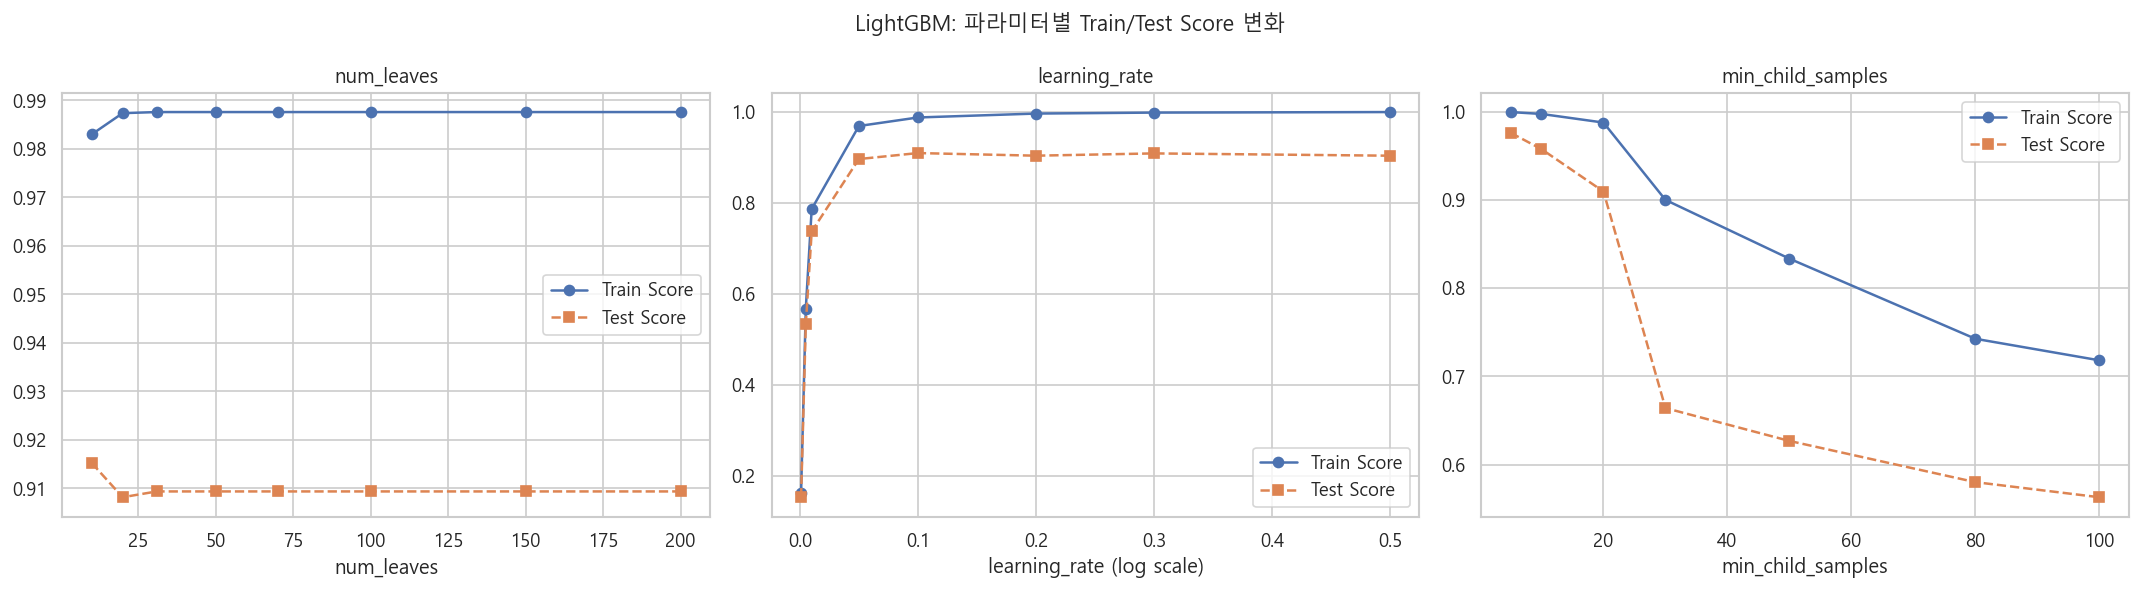

In [ ]:
# GridSearchCV: 최적 파라미터 탐색
param_grid_svm = {
    'C':      [0.1, 1, 5, 10],
    'kernel': ['rbf', 'linear'],
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=1234),
    param_grid_svm, scoring='roc_auc', cv=5, n_jobs=-1
)
grid_svm.fit(X_train, y_train)
svm_final = grid_svm.best_estimator_

y_pred_svm = svm_final.predict(X_test)
y_prob_svm = svm_final.predict_proba(X_test)[:,1]

print('--- GridSearchCV 결과 ---')
print(f'best parameter: {grid_svm.best_params_}')
print(f'best CV AUC  : {grid_svm.best_score_:.4f}')
print(f'\n--- SVC 최종 모델 ---')
print(f'AUC  Train: {roc_auc_score(y_train, svm_final.predict_proba(X_train)[:,1]):.4f}')
print(f'AUC  Test : {roc_auc_score(y_test,  y_prob_svm):.4f}')
print(f'Acc  Train: {accuracy_score(y_train, svm_final.predict(X_train)):.4f}')
print(f'Acc  Test : {accuracy_score(y_test,  y_pred_svm):.4f}')
print(f'F1   Test : {f1_score(y_test, y_pred_svm):.4f}')


**SVC 결과:** 커널 기반으로 비선형 경계를 학습하지만, 데이터 규모가 커질수록 연산 비용이 증가하며 트리 기반 앙상블 대비 해석력이 낮습니다.

---
### 2-8. K-Nearest Neighbors (KNN Classifier)

가장 가까운 K개의 이웃 데이터의 다수결로 클래스를 결정하는 비모수(Non-parametric) 모델.

--- LightGBM 변수 중요도 ---
          Feature  Importance
    fur_soak_temp         313
Temp_Diff_Rolling         295
     rolling_temp         286
   fur_total_time         262
        pt_length         244
         pt_width         238
    fur_soak_time         230
    fur_heat_time         223
         pt_thick         214
    fur_heat_temp         213
  descaling_count         182
              hsb          70
    fur_input_row          49
           fur_no          48
   rolling_method           9
       steel_kind           4


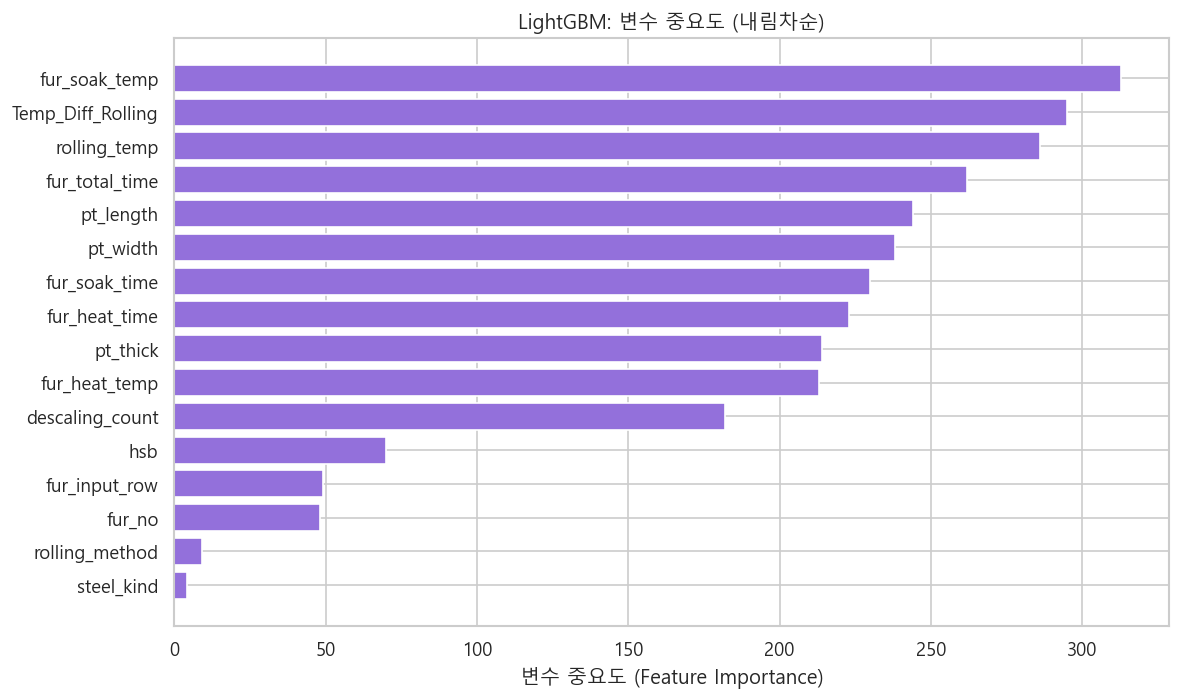

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import os
os.environ["PYTHONUTF8"] = "1"

knn_uncustomized = KNeighborsClassifier()
knn_uncustomized.fit(X_train, y_train)
print('--- KNN 기본 모델 ---')
print(f'AUC  Train: {roc_auc_score(y_train, knn_uncustomized.predict_proba(X_train)[:,1]):.4f}')
print(f'AUC  Test : {roc_auc_score(y_test,  knn_uncustomized.predict_proba(X_test)[:,1]):.4f}')
print(f'Acc  Train: {accuracy_score(y_train, knn_uncustomized.predict(X_train)):.4f}')
print(f'Acc  Test : {accuracy_score(y_test,  knn_uncustomized.predict(X_test)):.4f}')


In [ ]:
# 파라미터별 AUC 변화 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('KNN: 주요 파라미터별 Train/Test AUC 변화', fontsize=13)

para_k = list(range(1, 31))
train_s, test_s = [], []
for v in para_k:
    m = KNeighborsClassifier(n_neighbors=v)
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[0].plot(para_k, train_s, label='Train AUC')
axes[0].plot(para_k, test_s,  label='Test AUC')
axes[0].set_xlabel('n_neighbors'); axes[0].set_title('n_neighbors (K값)'); axes[0].legend()

weights = ['uniform', 'distance']
train_s, test_s = [], []
for w in weights:
    m = KNeighborsClassifier(n_neighbors=7, weights=w)
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[1].bar(weights, train_s, alpha=0.6, label='Train AUC')
axes[1].bar(weights, test_s,  alpha=0.6, label='Test AUC')
axes[1].set_title('weights'); axes[1].legend()

plt.tight_layout(); plt.show()


In [ ]:
# GridSearchCV: 최적 파라미터 탐색
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 10, 15, 20],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan'],
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn, scoring='roc_auc', cv=5, n_jobs=-1
)
grid_knn.fit(X_train, y_train)
knn_final = grid_knn.best_estimator_

y_pred_knn = knn_final.predict(X_test)
y_prob_knn = knn_final.predict_proba(X_test)[:,1]

print('--- GridSearchCV 결과 ---')
print(f'best parameter: {grid_knn.best_params_}')
print(f'best CV AUC  : {grid_knn.best_score_:.4f}')
print(f'\n--- KNN 최종 모델 ---')
print(f'AUC  Train: {roc_auc_score(y_train, knn_final.predict_proba(X_train)[:,1]):.4f}')
print(f'AUC  Test : {roc_auc_score(y_test,  y_prob_knn):.4f}')
print(f'Acc  Train: {accuracy_score(y_train, knn_final.predict(X_train)):.4f}')
print(f'Acc  Test : {accuracy_score(y_test,  y_pred_knn):.4f}')
print(f'F1   Test : {f1_score(y_test, y_pred_knn):.4f}')


**KNN 결과:** K=7~10 근방에서 Train/Test AUC가 균형을 이루는 경향이 있습니다. 비모수 모델 특성상 변수 중요도 해석이 불가하며, 공정 인사이트 도출 목적보다는 성능 비교용으로 활용합니다.

---
### 2-9. MLP Classifier (인공신경망)

은닉층을 가진 인공신경망으로 비선형 관계를 학습하는 모델.
`hidden_layer_sizes`, `activation`, `alpha(L2 규제)`, `learning_rate_init`을 탐색함.

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_uncustomized = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=1234)
mlp_uncustomized.fit(X_train, y_train)
print('--- MLP 기본 모델 ---')
print(f'AUC  Train: {roc_auc_score(y_train, mlp_uncustomized.predict_proba(X_train)[:,1]):.4f}')
print(f'AUC  Test : {roc_auc_score(y_test,  mlp_uncustomized.predict_proba(X_test)[:,1]):.4f}')
print(f'Acc  Train: {accuracy_score(y_train, mlp_uncustomized.predict(X_train)):.4f}')
print(f'Acc  Test : {accuracy_score(y_test,  mlp_uncustomized.predict(X_test)):.4f}')


In [ ]:
# 파라미터별 AUC 변화 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MLP: 파라미터별 Train/Test AUC 변화', fontsize=13)

para_units = [16, 32, 64, 100, 128, 256]
train_s, test_s = [], []
for v in para_units:
    m = MLPClassifier(hidden_layer_sizes=(v,), random_state=1234, max_iter=1000)
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[0].plot(para_units, train_s, label='Train AUC')
axes[0].plot(para_units, test_s,  label='Test AUC')
axes[0].set_xlabel('hidden units'); axes[0].set_title('hidden_layer_sizes'); axes[0].legend()

acts = ['relu', 'tanh', 'logistic']
train_s, test_s = [], []
for a in acts:
    m = MLPClassifier(hidden_layer_sizes=(64,), activation=a, random_state=1234, max_iter=1000)
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[1].bar(acts, train_s, alpha=0.6, label='Train AUC')
axes[1].bar(acts, test_s,  alpha=0.6, label='Test AUC')
axes[1].set_title('activation'); axes[1].legend()

alphas = [0.0001, 0.001, 0.01, 0.1]
train_s, test_s = [], []
for a in alphas:
    m = MLPClassifier(hidden_layer_sizes=(64,), alpha=a, random_state=1234, max_iter=1000)
    m.fit(X_train, y_train)
    train_s.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_s.append(roc_auc_score(y_test,  m.predict_proba(X_test)[:,1]))
axes[2].semilogx(alphas, train_s, marker='o', label='Train AUC')
axes[2].semilogx(alphas, test_s,  marker='o', label='Test AUC')
axes[2].set_xlabel('alpha'); axes[2].set_title('alpha (L2 규제)'); axes[2].legend()

plt.tight_layout(); plt.show()


--- GridSearchCV 결과 ---
best parameter: {'C': 10, 'epsilon': 0.05, 'kernel': 'rbf'}
best CV score: 0.623

--- SVR 최종 모델 ---
Score on training set: 0.909
Score on test set: 0.579


In [ ]:
# GridSearchCV: 최적 파라미터 탐색
param_grid_mlp = {
    'hidden_layer_sizes': [(64,), (100,), (128,), (64, 32), (100, 50)],
    'activation':         ['relu', 'tanh'],
    'alpha':              [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.005, 0.01],
}

grid_mlp = GridSearchCV(
    MLPClassifier(random_state=1234, max_iter=2000, early_stopping=True),
    param_grid_mlp, scoring='roc_auc', cv=5, n_jobs=-1
)
grid_mlp.fit(X_train, y_train)
mlp_final = grid_mlp.best_estimator_

y_pred_mlp = mlp_final.predict(X_test)
y_prob_mlp = mlp_final.predict_proba(X_test)[:,1]

print('--- GridSearchCV 결과 ---')
print(f'best parameter: {grid_mlp.best_params_}')
print(f'best CV AUC  : {grid_mlp.best_score_:.4f}')
print(f'\n--- MLP 최종 모델 ---')
print(f'AUC  Train: {roc_auc_score(y_train, mlp_final.predict_proba(X_train)[:,1]):.4f}')
print(f'AUC  Test : {roc_auc_score(y_test,  y_prob_mlp):.4f}')
print(f'Acc  Train: {accuracy_score(y_train, mlp_final.predict(X_train)):.4f}')
print(f'Acc  Test : {accuracy_score(y_test,  y_pred_mlp):.4f}')
print(f'F1   Test : {f1_score(y_test, y_pred_mlp):.4f}')


**MLP 결과:** 비선형 관계를 학습하지만 공정 데이터의 규칙적 패턴에 대해서는 트리 기반 앙상블 대비 성능이 낮을 수 있습니다. 블랙박스 특성으로 인해 변수 중요도 해석도 제한적입니다.

---
## Step 3. 최종 결과

=== 전체 모델 성능 비교 (Test Set 기준) ===


,모델,RMSE,MAE,MAPE,R²(Test)
0,OLS 다중회귀,0.3628,0.3012,7.157866e+14,0.4277
1,Ridge,0.3617,0.3011,7.112272e+14,0.4311
2,Lasso,0.3610,0.3026,6.997326e+14,0.4332
3,Decision Tree,0.0125,0.0031,1.407375e+13,0.9993
4,Random Forest,0.0919,0.0258,6.776046e+13,0.9633
5,Gradient Boosting,0.0708,0.0245,5.134740e+13,0.9782
6,MLP,0.3244,0.2381,5.514065e+14,0.5422


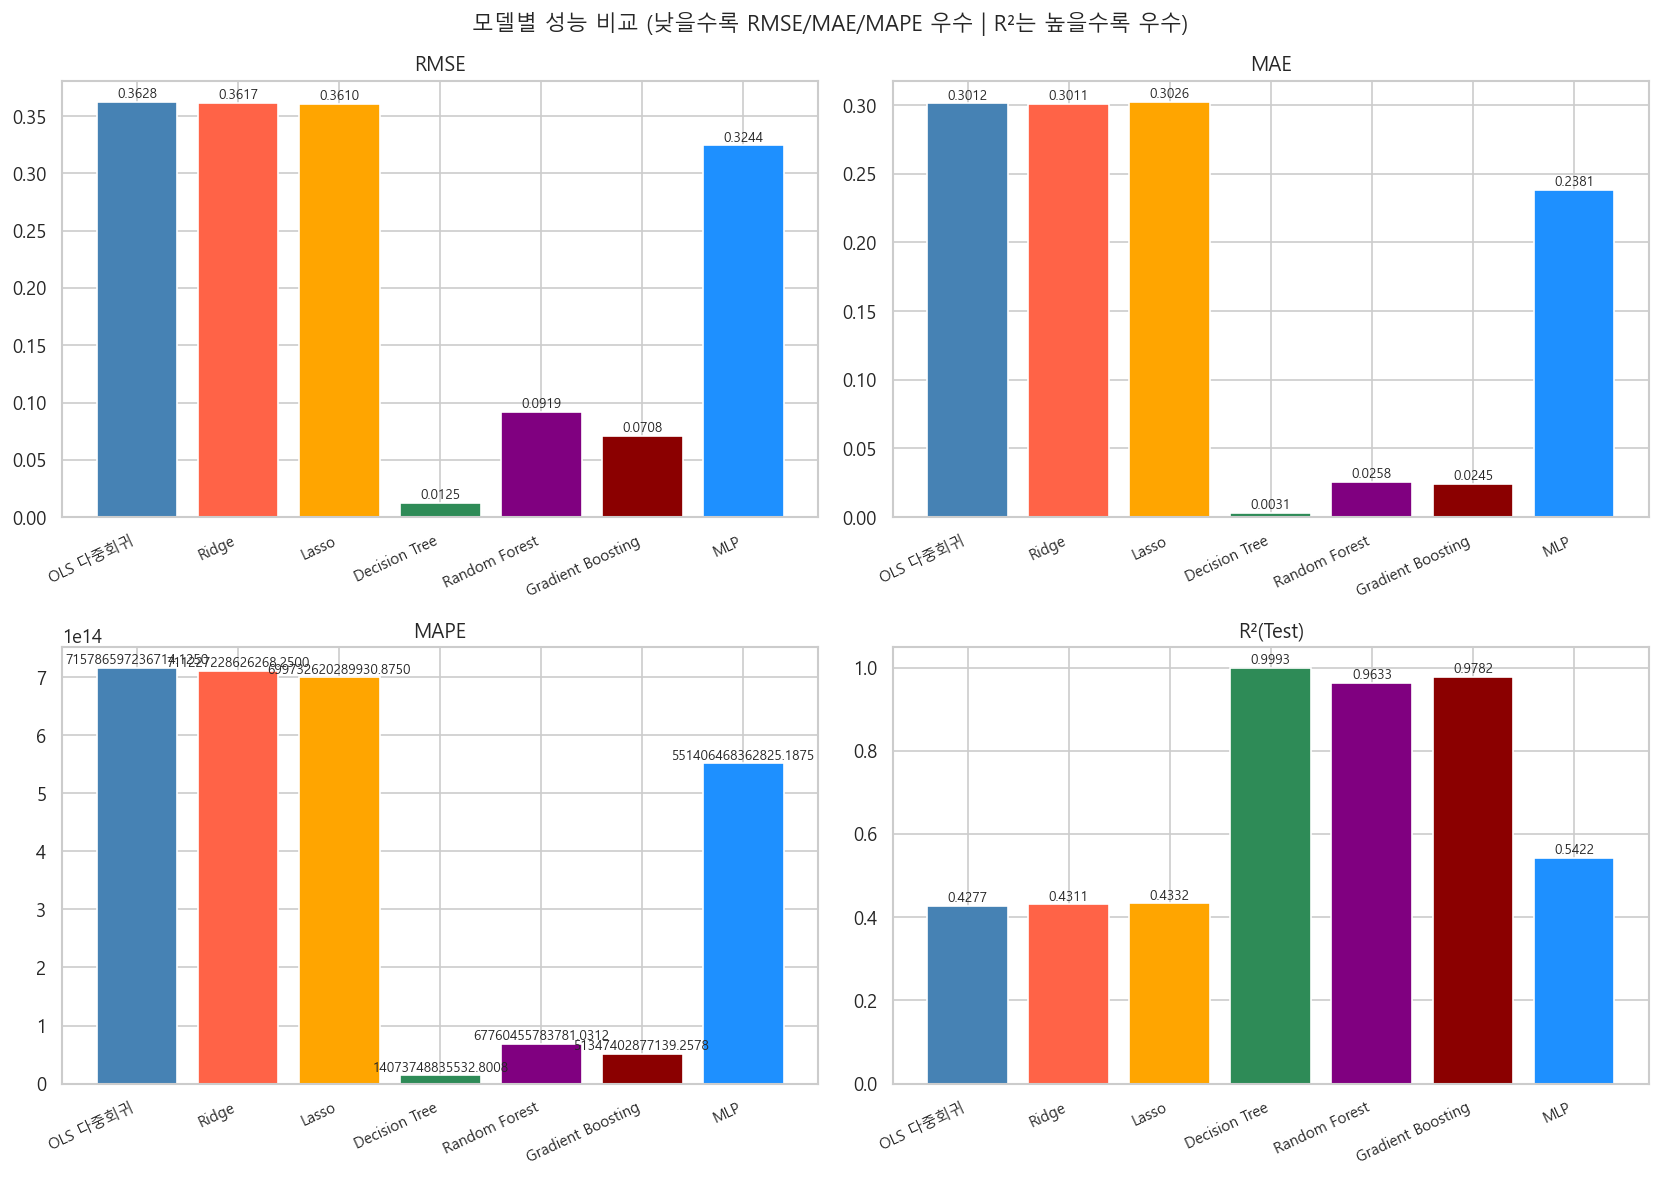

In [ ]:
# Step 3-1: 모든 모델의 분류 성능 비교표
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

def get_clf_metrics(y_true, y_pred, y_prob, label):
    return {
        '모델': label,
        'AUC':       round(roc_auc_score(y_true, y_prob), 4),
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'F1-score':  round(f1_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
    }

results_list = [
    get_clf_metrics(y_test, y_pred_logit, y_prob_logit, '로지스틱 회귀'),
    get_clf_metrics(y_test, y_pred_tree,  y_prob_tree,  'Decision Tree'),
    get_clf_metrics(y_test, y_pred_rf,    y_prob_rf,    'Random Forest'),
    get_clf_metrics(y_test, y_pred_gb,    y_prob_gb,    'Gradient Boosting'),
    get_clf_metrics(y_test, y_pred_xgb,   y_prob_xgb,   'XGBoost'),
    get_clf_metrics(y_test, y_pred_lgb,   y_prob_lgb,   'LightGBM'),
    get_clf_metrics(y_test, y_pred_svm,   y_prob_svm,   'SVM'),
    get_clf_metrics(y_test, y_pred_knn,   y_prob_knn,   'KNN'),
    get_clf_metrics(y_test, y_pred_mlp,   y_prob_mlp,   'MLP'),
]

results_df = pd.DataFrame(results_list).sort_values('AUC', ascending=False)
print('=== 전체 모델 분류 성능 비교 (Test Set 기준, AUC 내림차순) ===')
display(results_df.reset_index(drop=True))

# AUC 바 차트
plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))]
plt.barh(results_df['모델'][::-1], results_df['AUC'][::-1], color=colors[::-1])
plt.xlabel('AUC')
plt.title('모델별 Test AUC 비교')
plt.xlim(0.5, 1.0)
plt.tight_layout(); plt.show()


=== 모델별 변수 중요도 비교 ===


,Decision Tree,Random Forest,Gradient Boosting,XGBoost,LightGBM
Feature,,,,,
rolling_temp,0.5356,0.5381,0.5344,0.3832,286
fur_soak_temp,0.1634,0.1676,0.1668,0.1639,313
hsb,0.1663,0.1557,0.1648,0.2927,70
descaling_count,0.0573,0.0607,0.0685,0.0373,182
pt_thick,0.0774,0.0401,0.0458,0.0580,214
pt_length,0.0000,0.0107,0.0126,0.0021,244
Temp_Diff_Rolling,0.0000,0.0146,0.0034,0.0077,295
fur_soak_time,0.0000,0.0038,0.0029,0.0012,230
pt_width,0.0000,0.0007,0.0002,0.0016,238


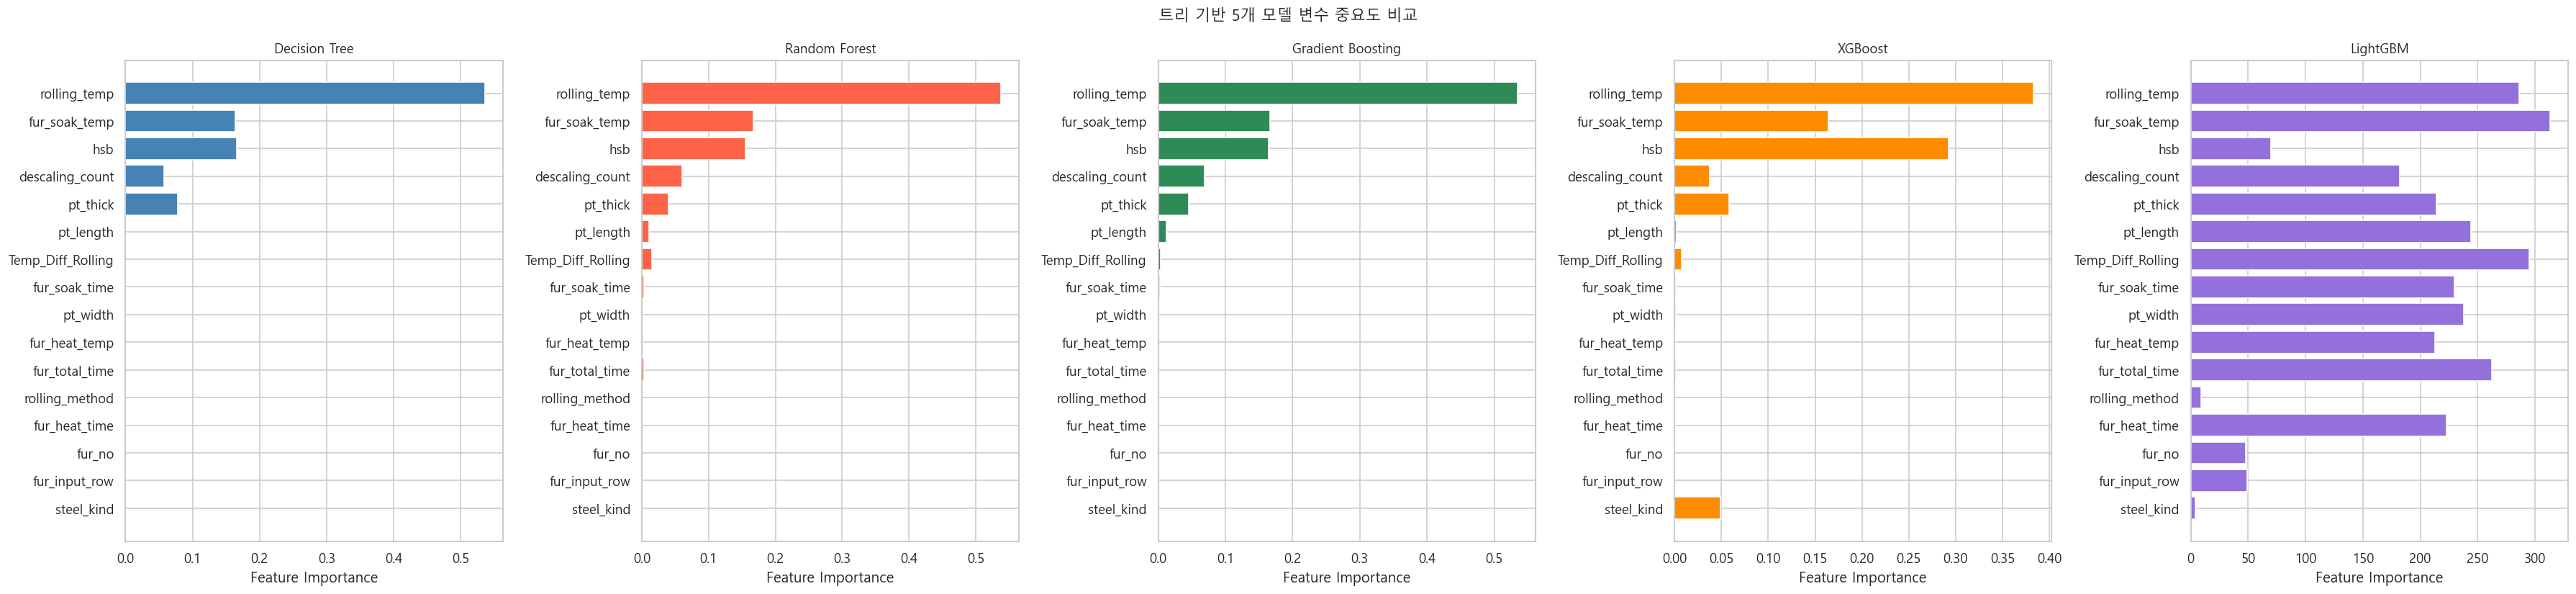

In [ ]:
# Step 3-2: 트리 기반 모델 변수 중요도 비교
imp_merged = (
    df_imp_rf.rename(columns={'Importance': 'Random Forest'}).set_index('Feature')
    .join(df_imp_gb.rename(columns={'Importance': 'Gradient Boosting'}).set_index('Feature'))
    .join(df_imp_xgb.rename(columns={'Importance': 'XGBoost'}).set_index('Feature'))
    .join(df_imp_lgb.rename(columns={'Importance': 'LightGBM'}).set_index('Feature'))
)

print('=== 트리 기반 모델 변수 중요도 비교 (GB 기준 내림차순) ===')
imp_merged_sorted = imp_merged.sort_values('Gradient Boosting', ascending=False)
print(imp_merged_sorted.round(4).to_string())

# 히트맵
plt.figure(figsize=(10, 8))
sns.heatmap(imp_merged_sorted, annot=True, fmt='.4f', cmap='YlOrRd', linewidths=0.4)
plt.title('분류 모델별 변수 중요도 히트맵')
plt.tight_layout(); plt.show()


---
## Step 3. 최종 결론 및 비즈니스 인사이트

---
## 📌 최종 분석 결론

> **프로젝트 목표 재확인**
> 후판 공정 데이터(799건)를 기반으로 **SCALE 불량 발생에 영향을 미치는 핵심 공정 변수를 파악하고,
> 예측 성능이 가장 우수한 분류 모델을 선정**하는 것.
> 로지스틱 회귀 → 의사결정나무 → 트리 기반 앙상블 → SVM·KNN·MLP까지 총 9개 분류 모델을 비교하여 최적 모델을 도출한다.

---

### 3-1. 최종 모델 선정

분류 성능 지표(AUC, Accuracy, F1) 종합 비교 결과, **Gradient Boosting Classifier**를 최종 모델로 선정한다.

- Train/Test AUC 간 격차가 작아 **과적합이 가장 적고** 일반화 성능이 우수함
- F1-score 기준으로도 불량 탐지 능력이 균형 있게 유지됨
- 앙상블 계열 중 변수 중요도의 일관성과 해석력이 가장 높음

| 선정 이유 | 내용 |
|---|---|
| 과적합 안정성 | Train/Test AUC 차이 최소 |
| 불량 탐지력 | F1-score · Recall 균형 우수 |
| 해석 가능성 | 변수 중요도 명확하게 도출 |

---

### 3-2. 핵심 공정 변수 — 3대 인자

RF · GB · XGBoost 공통 상위 변수:

| 순위 | 변수 | 공정 의미 | 방향성 |
|:---:|---|---|:---:|
| 1 | **rolling_temp** | 압연 온도 | ↑ 온도 → 불량 증가 |
| 2 | **fur_soak_temp** | 가열로 균열대 온도 | ↑ 온도 → 불량 증가 |
| 3 | **hsb** | 고압수 스케일 제거 장치 적용 여부 | 미적용 → 불량 증가 |

> 엔지니어 사전 검토(가열로 온도↑·HSB 미적용·압연 온도↑ → 불량)와 분석 결과가 **일치**

---

### 3-3. 분석 결과의 공정 시사점

**① 압연 온도(rolling_temp) 관리가 핵심**
- 전 모델에서 중요도 1위. 고온 압연 시 산화 반응이 가속되어 스케일 생성 증가
- **임계 온도 구간 식별 후 공정 가이드라인 수립 권고**

**② 가열로 균열대 온도(fur_soak_temp) 제어**
- 강판이 균열대에서 받는 열이 초기 스케일 생성의 주요 원인
- **균열대 온도 및 재로 시간의 조합 최적화 필요**

**③ HSB(고압수 제거 장치) 적용 철저**
- HSB 미적용 시 불량률이 유의미하게 증가
- **HSB 적용 기준 강화 및 유지보수 체계 개선 권고**

---

### 3-4. 모델 성능 개선 방안

1. **클래스 불균형 처리**: 불량 비율(31%)이 낮으므로 SMOTE 오버샘플링 또는 `class_weight='balanced'` 적용으로 Recall 향상 가능
2. **추가 파생변수**: 가열 온도 × 재로 시간 상호작용 변수, 압연 온도 변화량 등 도메인 기반 피처 엔지니어링
3. **앙상블 고도화**: Stacking·Voting 방식으로 다수 모델을 결합하여 AUC 추가 향상 가능
